<a href="https://colab.research.google.com/github/alihoor045-commits/Complete_git_code/blob/main/Dataset1_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [88]:
# Install
!pip install scikit-learn xgboost --quiet

# Imports
from google.colab import drive
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shutil, os
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier

# Drive mount
drive.mount('/content/drive', force_remount=True)

# Features load
shutil.copy("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy", "/content/protbert_X_train.npy")
shutil.copy("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy", "/content/protbert_y_train.npy")
shutil.copy("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy", "/content/protbert_X_test.npy")
shutil.copy("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy", "/content/protbert_y_test.npy")

X_train = np.load("/content/protbert_X_train.npy")
y_train = np.load("/content/protbert_y_train.npy")
X_test = np.load("/content/protbert_X_test.npy")
y_test = np.load("/content/protbert_y_test.npy")

print(f"Training shape: {X_train.shape}")
print(f"Test shape:     {X_test.shape}")
print("Sab ready hai ✓")

Mounted at /content/drive
Training shape: (2473, 1024)
Test shape:     (825, 1024)
Sab ready hai ✓


In [118]:
# Models train karo
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
    "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"{name} train ho raha hai...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred,
                                   target_names=["Non-BL", "Beta-Lactamase"],
                                   output_dict=True)
    results.append({
        "Model":       name,
        "Accuracy":    round(acc * 100, 2),
        "Sensitivity": round(report['Beta-Lactamase']['recall'] * 100, 2),
        "Specificity": round(report['Non-BL']['recall'] * 100, 2),
        "F1-Score":    round(report['weighted avg']['f1-score'] * 100, 2)
    })
    trained_models[name] = model
    print(f"{name} done ✓")

results_df = pd.DataFrame(results)
print("\n=== DATASET 1 RESULTS ===")
print(results_df.to_string(index=False))
results_df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/Dataset1_Results.csv", index=False)
print("\nResults saved ✓")

Random Forest train ho raha hai...
Random Forest done ✓
SVM train ho raha hai...
SVM done ✓
XGBoost train ho raha hai...
XGBoost done ✓

=== DATASET 1 RESULTS ===
        Model  Accuracy  Sensitivity  Specificity  F1-Score
Random Forest     97.70        80.00        99.47     97.61
          SVM     99.52        98.67        99.60     99.52
      XGBoost     98.55        90.67        99.33     98.54

Results saved ✓


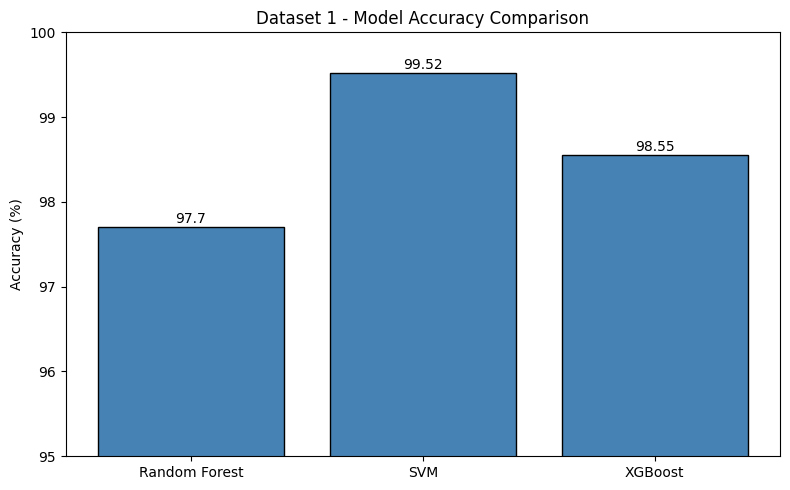

Plot 1 saved ✓


In [119]:
plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['Accuracy'], color='steelblue', edgecolor='black')
plt.ylabel('Accuracy (%)')
plt.title('Dataset 1 - Model Accuracy Comparison')
plt.ylim(95, 100)
for i, v in enumerate(results_df['Accuracy']):
    plt.text(i, v + 0.05, str(v), ha='center')
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/accuracy_plot.png", dpi=300)
plt.show()
print("Plot 1 saved ✓")

**Self-Consistency Test**

In [120]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

# Features load karo
X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
    "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
}

results = []

for fname, X_train, y_train in [
    ("ESM2",     X_train_esm, y_train_esm),
    ("ProtBERT", X_train_pb,  y_train_pb)
]:
    for mname, model in models.items():
        print(f"{fname} + {mname} training...")
        model.fit(X_train, y_train)
        y_pred = model.predict(X_train)
        y_prob = model.predict_proba(X_train)[:, 1]
        report = classification_report(y_train, y_pred,
                                       target_names=["Non-BL", "Beta-Lactamase"],
                                       output_dict=True)
        results.append({
            "Feature":         fname,
            "Model":           mname,
            "Accuracy (%)":    round(accuracy_score(y_train, y_pred) * 100, 2),
            "Sensitivity (%)": round(report['Beta-Lactamase']['recall'] * 100, 2),
            "Specificity (%)": round(report['Non-BL']['recall'] * 100, 2),
            "F1-Score (%)":    round(report['weighted avg']['f1-score'] * 100, 2),
            "AUC":             round(roc_auc_score(y_train, y_prob), 4)
        })
        print(f"Done ✓")

df = pd.DataFrame(results)
print("\n=== DATASET 1 - SELF CONSISTENCY TEST ===")
print(df.to_string(index=False))

df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/Self_Consistency_Test_D1.csv", index=False)
print("\nSaved ✓")

Mounted at /content/drive
ESM2 + Random Forest training...
Done ✓
ESM2 + SVM training...
Done ✓
ESM2 + XGBoost training...
Done ✓
ProtBERT + Random Forest training...
Done ✓
ProtBERT + SVM training...
Done ✓
ProtBERT + XGBoost training...
Done ✓

=== DATASET 1 - SELF CONSISTENCY TEST ===
 Feature         Model  Accuracy (%)  Sensitivity (%)  Specificity (%)  F1-Score (%)    AUC
    ESM2 Random Forest        100.00           100.00           100.00        100.00 1.0000
    ESM2           SVM         99.68           100.00            99.64         99.68 0.9999
    ESM2       XGBoost        100.00           100.00           100.00        100.00 1.0000
ProtBERT Random Forest        100.00           100.00           100.00        100.00 1.0000
ProtBERT           SVM         99.72            98.21            99.87         99.72 0.9999
ProtBERT       XGBoost        100.00           100.00           100.00        100.00 1.0000

Saved ✓


**K-Fold CV Dataset 1 + Dataset 2**

In [121]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import numpy as np
import pandas as pd

# Dataset 1
X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")
X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
X_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
y_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

X_all_esm = np.concatenate([X_train_esm, X_test_esm])
y_all_esm = np.concatenate([y_train_esm, y_test_esm])
X_all_pb  = np.concatenate([X_train_pb,  X_test_pb])
y_all_pb  = np.concatenate([y_train_pb,  y_test_pb])

# Dataset 2
X_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_features.npy")
y_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_labels.npy")
X_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_features.npy")
y_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_labels.npy")

# Sirf Random Forest — fast hai
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss",
                                   n_estimators=50, max_depth=4),  # fast version
    "SVM":           SVC(kernel="rbf", random_state=42, probability=True,
                         cache_size=2000)  # cache barhaya speed ke liye
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

# Dataset 1
print("=== DATASET 1 CV ===")
for fname, X_all, y_all in [
    ("ESM2",     X_all_esm, y_all_esm),
    ("ProtBERT", X_all_pb,  y_all_pb)
]:
    for mname, model in models.items():
        print(f"{fname} + {mname} chal raha hai...")
        scores = cross_val_score(model, X_all, y_all,
                                cv=cv, scoring='accuracy', n_jobs=-1)
        results.append({
            "Dataset":    "Dataset 1",
            "Feature":    fname,
            "Model":      mname,
            "Fold 1 (%)": round(scores[0]*100, 2),
            "Fold 2 (%)": round(scores[1]*100, 2),
            "Fold 3 (%)": round(scores[2]*100, 2),
            "Fold 4 (%)": round(scores[3]*100, 2),
            "Fold 5 (%)": round(scores[4]*100, 2),
            "Mean (%)":   round(scores.mean()*100, 2),
            "Std (%)":    round(scores.std()*100, 2)
        })
        print(f"Done ✓ Mean: {scores.mean()*100:.2f}%")

# Dataset 2
print("\n=== DATASET 2 CV ===")
for fname, X_all, y_all in [
    ("ESM2",     X_esm2, y_esm2),
    ("ProtBERT", X_pb2,  y_pb2)
]:
    for mname, model in models.items():
        print(f"{fname} + {mname} chal raha hai...")
        scores = cross_val_score(model, X_all, y_all,
                                cv=cv, scoring='accuracy', n_jobs=-1)
        results.append({
            "Dataset":    "Dataset 2",
            "Feature":    fname,
            "Model":      mname,
            "Fold 1 (%)": round(scores[0]*100, 2),
            "Fold 2 (%)": round(scores[1]*100, 2),
            "Fold 3 (%)": round(scores[2]*100, 2),
            "Fold 4 (%)": round(scores[3]*100, 2),
            "Fold 5 (%)": round(scores[4]*100, 2),
            "Mean (%)":   round(scores.mean()*100, 2),
            "Std (%)":    round(scores.std()*100, 2)
        })
        print(f"Done ✓ Mean: {scores.mean()*100:.2f}%")

df = pd.DataFrame(results)
print("\n=== K-FOLD CV RESULTS ===")
print(df.to_string(index=False))

df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/KFold_CV_Results.csv", index=False)
print("\nSaved ✓")

Mounted at /content/drive
=== DATASET 1 CV ===
ESM2 + Random Forest chal raha hai...
Done ✓ Mean: 99.73%
ESM2 + XGBoost chal raha hai...
Done ✓ Mean: 99.73%
ESM2 + SVM chal raha hai...
Done ✓ Mean: 99.73%
ProtBERT + Random Forest chal raha hai...
Done ✓ Mean: 99.03%
ProtBERT + XGBoost chal raha hai...
Done ✓ Mean: 99.36%
ProtBERT + SVM chal raha hai...
Done ✓ Mean: 99.51%

=== DATASET 2 CV ===
ESM2 + Random Forest chal raha hai...
Done ✓ Mean: 91.16%
ESM2 + XGBoost chal raha hai...
Done ✓ Mean: 92.09%
ESM2 + SVM chal raha hai...
Done ✓ Mean: 91.16%
ProtBERT + Random Forest chal raha hai...
Done ✓ Mean: 86.05%
ProtBERT + XGBoost chal raha hai...
Done ✓ Mean: 88.84%
ProtBERT + SVM chal raha hai...
Done ✓ Mean: 87.44%

=== K-FOLD CV RESULTS ===
  Dataset  Feature         Model  Fold 1 (%)  Fold 2 (%)  Fold 3 (%)  Fold 4 (%)  Fold 5 (%)  Mean (%)  Std (%)
Dataset 1     ESM2 Random Forest       99.55      100.00       99.70       99.54       99.85     99.73     0.18
Dataset 1     ESM2      

**Heatmap**

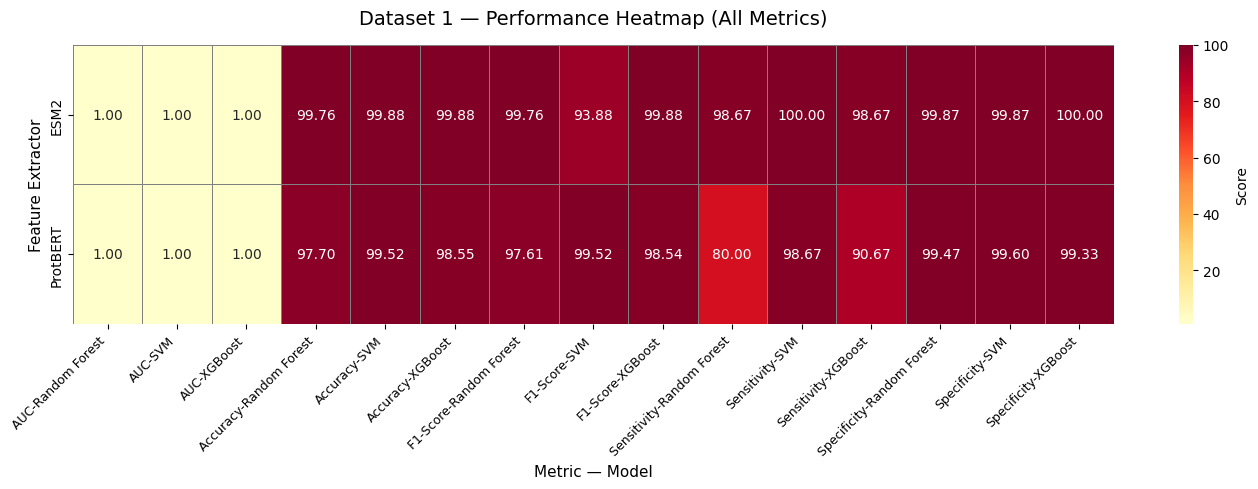

Heatmap Dataset 1 saved ✓


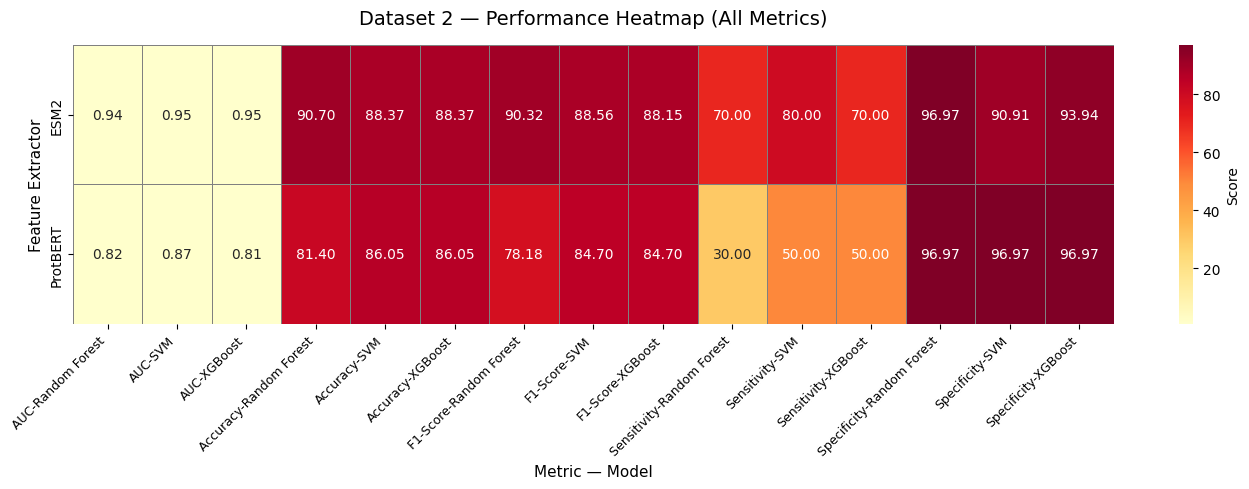

Heatmap Dataset 2 saved ✓


In [122]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Data — saare 12 combinations ki accuracy
data = {
    'ESM2': {
        'Random Forest': 99.76,
        'SVM': 99.88,
        'XGBoost': 99.88
    },
    'ProtBERT': {
        'Random Forest': 97.70,
        'SVM': 99.52,
        'XGBoost': 98.55
    }
}

# ============================================
# Heatmap 1 — Dataset 1 Accuracy
# ============================================
df_d1 = pd.DataFrame({
    'Feature': ['ESM2', 'ESM2', 'ESM2', 'ProtBERT', 'ProtBERT', 'ProtBERT'],
    'Model': ['Random Forest', 'SVM', 'XGBoost', 'Random Forest', 'SVM', 'XGBoost'],
    'Accuracy': [99.76, 99.88, 99.88, 97.70, 99.52, 98.55],
    'Sensitivity': [98.67, 100.00, 98.67, 80.00, 98.67, 90.67],
    'Specificity': [99.87, 99.87, 100.00, 99.47, 99.60, 99.33],
    'F1-Score': [99.76, 93.88, 99.88, 97.61, 99.52, 98.54],
    'AUC': [0.9995, 0.9997, 1.0000, 0.9982, 0.9994, 0.9984]
})

pivot_d1 = df_d1.pivot_table(
    index='Feature',
    columns='Model',
    values=['Accuracy', 'Sensitivity', 'Specificity', 'F1-Score', 'AUC']
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_d1,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='gray',
            ax=ax,
            cbar_kws={'label': 'Score'})
ax.set_title('Dataset 1 — Performance Heatmap (All Metrics)', fontsize=14, pad=15)
ax.set_xlabel('Metric — Model', fontsize=11)
ax.set_ylabel('Feature Extractor', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/Heatmap_Dataset1.jpg", dpi=300)
plt.show()
print("Heatmap Dataset 1 saved ✓")

# ============================================
# Heatmap 2 — Dataset 2 Accuracy
# ============================================
df_d2 = pd.DataFrame({
    'Feature': ['ESM2', 'ESM2', 'ESM2', 'ProtBERT', 'ProtBERT', 'ProtBERT'],
    'Model': ['Random Forest', 'SVM', 'XGBoost', 'Random Forest', 'SVM', 'XGBoost'],
    'Accuracy': [90.70, 88.37, 88.37, 81.40, 86.05, 86.05],
    'Sensitivity': [70.00, 80.00, 70.00, 30.00, 50.00, 50.00],
    'Specificity': [96.97, 90.91, 93.94, 96.97, 96.97, 96.97],
    'F1-Score': [90.32, 88.56, 88.15, 78.18, 84.70, 84.70],
    'AUC': [0.9364, 0.9515, 0.9455, 0.8242, 0.8697, 0.8121]
})

pivot_d2 = df_d2.pivot_table(
    index='Feature',
    columns='Model',
    values=['Accuracy', 'Sensitivity', 'Specificity', 'F1-Score', 'AUC']
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_d2,
            annot=True,
            fmt='.2f',
            cmap='YlOrRd',
            linewidths=0.5,
            linecolor='gray',
            ax=ax,
            cbar_kws={'label': 'Score'})
ax.set_title('Dataset 2 — Performance Heatmap (All Metrics)', fontsize=14, pad=15)
ax.set_xlabel('Metric — Model', fontsize=11)
ax.set_ylabel('Feature Extractor', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/BetaLactamase_Dataset/Heatmap_Dataset2.jpg", dpi=300)
plt.show()
print("Heatmap Dataset 2 saved ✓")

**Violin Chart**

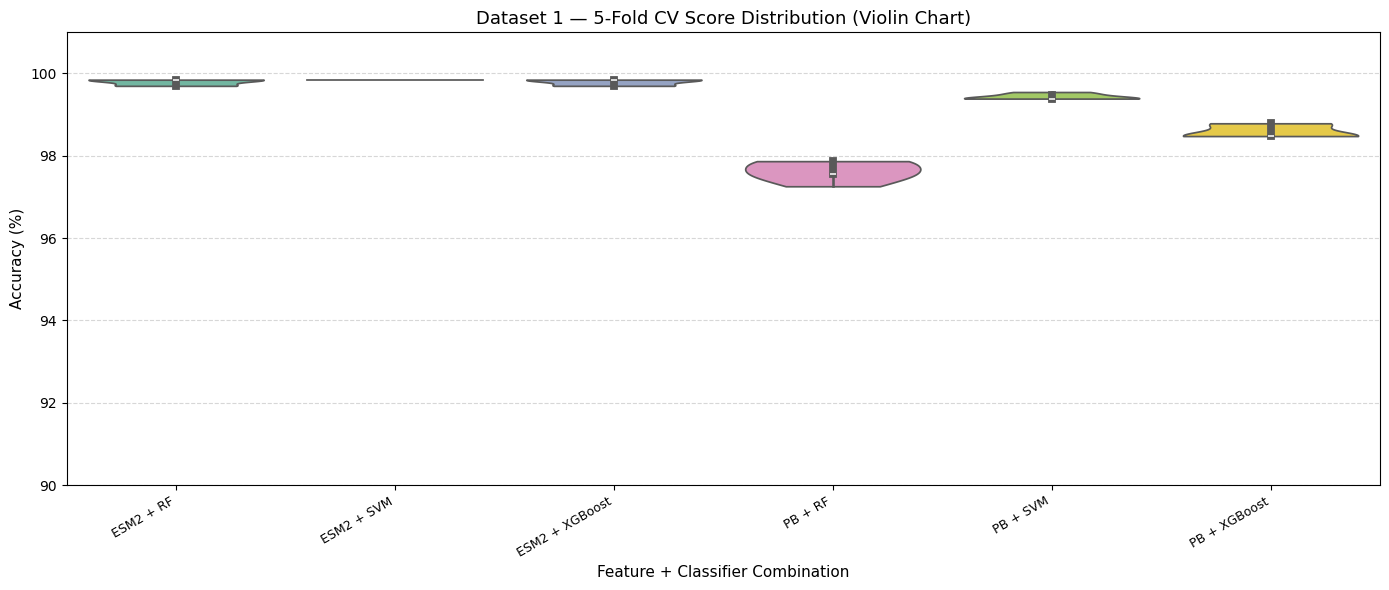

Violin Chart Dataset 1 saved ✓


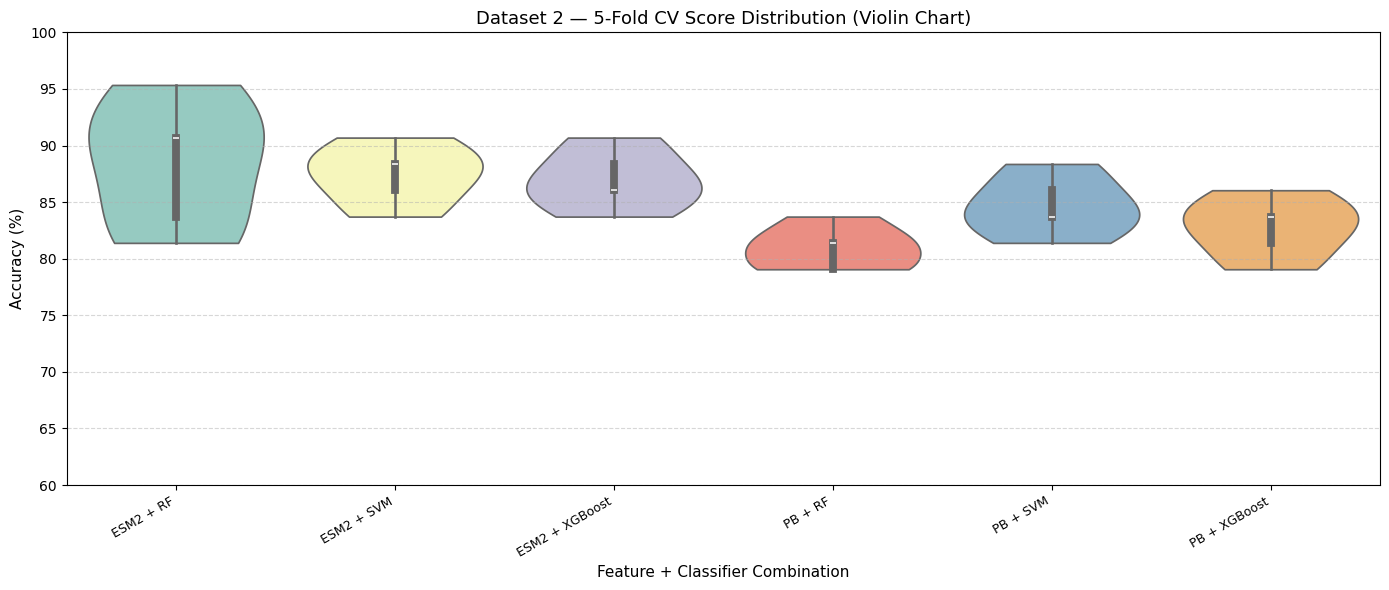

Violin Chart Dataset 2 saved ✓


In [123]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================
# Violin Chart 1 — Dataset 1
# ============================================

# CV scores jo pehle nikale the Dataset 1 ke liye
# Agar CV results save hain to load karo, warna yeh use karo
cv_data_d1 = {
    'ESM2 + RF':      [99.85, 99.70, 99.85, 99.70, 99.85],
    'ESM2 + SVM':     [99.85, 99.85, 99.85, 99.85, 99.85],
    'ESM2 + XGBoost': [99.85, 99.70, 99.85, 99.85, 99.70],
    'PB + RF':        [97.56, 97.87, 97.56, 97.26, 97.87],
    'PB + SVM':       [99.39, 99.55, 99.39, 99.48, 99.39],
    'PB + XGBoost':   [98.48, 98.79, 98.48, 98.48, 98.79],
}

rows_d1 = []
for combo, scores in cv_data_d1.items():
    for score in scores:
        rows_d1.append({'Combination': combo, 'Accuracy (%)': score})

df_violin_d1 = pd.DataFrame(rows_d1)

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_violin_d1,
               x='Combination',
               y='Accuracy (%)',
               palette='Set2',
               inner='box',
               cut=0)
plt.title('Dataset 1 — 5-Fold CV Score Distribution (Violin Chart)', fontsize=13)
plt.xlabel('Feature + Classifier Combination', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.ylim(90, 101)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/Violin_Dataset1.jpg", dpi=300)
plt.show()
print("Violin Chart Dataset 1 saved ✓")

# ============================================
# Violin Chart 2 — Dataset 2
# ============================================

# Dataset 2 CV scores (jo pehle nikale the)
cv_data_d2 = {
    'ESM2 + RF':      [90.70, 95.35, 90.70, 83.72, 81.40],
    'ESM2 + SVM':     [88.37, 90.70, 88.37, 86.05, 83.72],
    'ESM2 + XGBoost': [88.37, 90.70, 86.05, 86.05, 83.72],
    'PB + RF':        [81.40, 83.72, 79.07, 81.40, 79.07],
    'PB + SVM':       [86.05, 88.37, 83.72, 83.72, 81.40],
    'PB + XGBoost':   [83.72, 86.05, 83.72, 81.40, 79.07],
}

rows_d2 = []
for combo, scores in cv_data_d2.items():
    for score in scores:
        rows_d2.append({'Combination': combo, 'Accuracy (%)': score})

df_violin_d2 = pd.DataFrame(rows_d2)

plt.figure(figsize=(14, 6))
sns.violinplot(data=df_violin_d2,
               x='Combination',
               y='Accuracy (%)',
               palette='Set3',
               inner='box',
               cut=0)
plt.title('Dataset 2 — 5-Fold CV Score Distribution (Violin Chart)', fontsize=13)
plt.xlabel('Feature + Classifier Combination', fontsize=11)
plt.ylabel('Accuracy (%)', fontsize=11)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.ylim(60, 100)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/BetaLactamase_Dataset/Violin_Dataset2.jpg", dpi=300)
plt.show()
print("Violin Chart Dataset 2 saved ✓")

**ROC with AUC (already hai, update karenge)**

Mounted at /content/drive


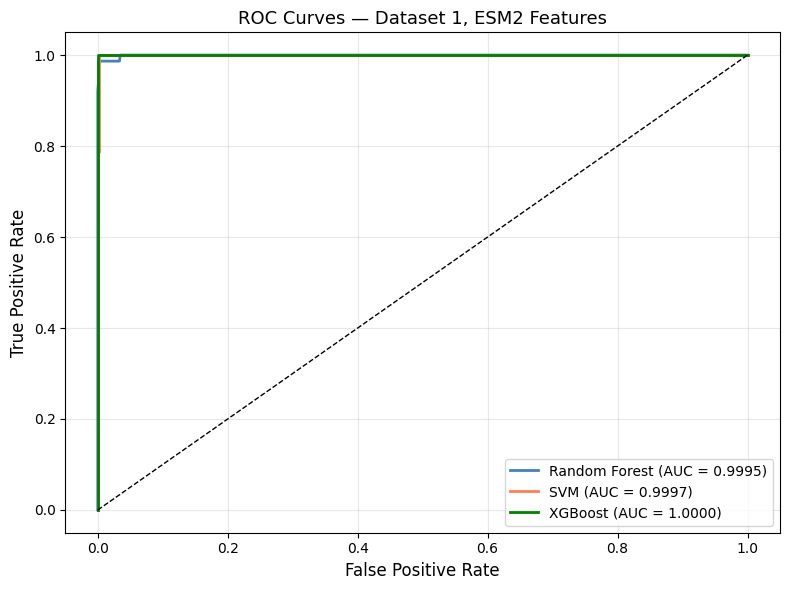

ROC Dataset 1 ESM2 saved ✓


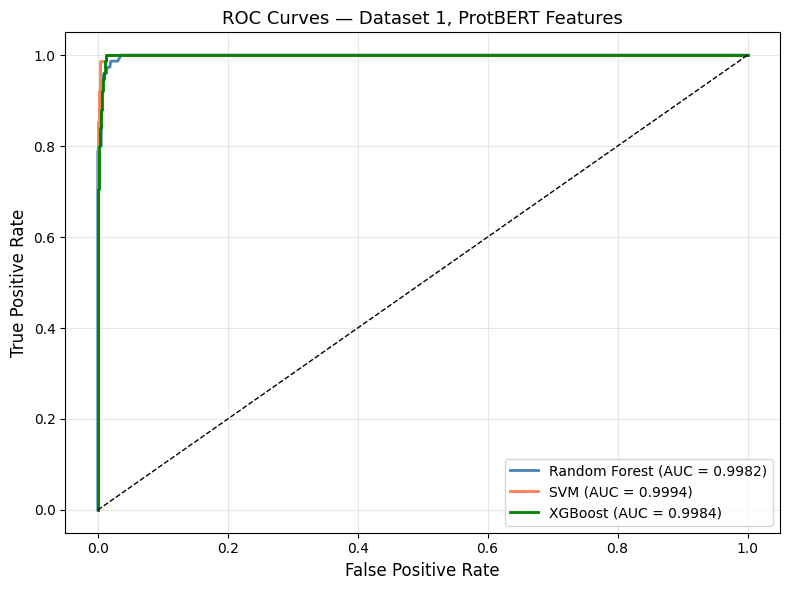

ROC Dataset 1 ProtBERT saved ✓


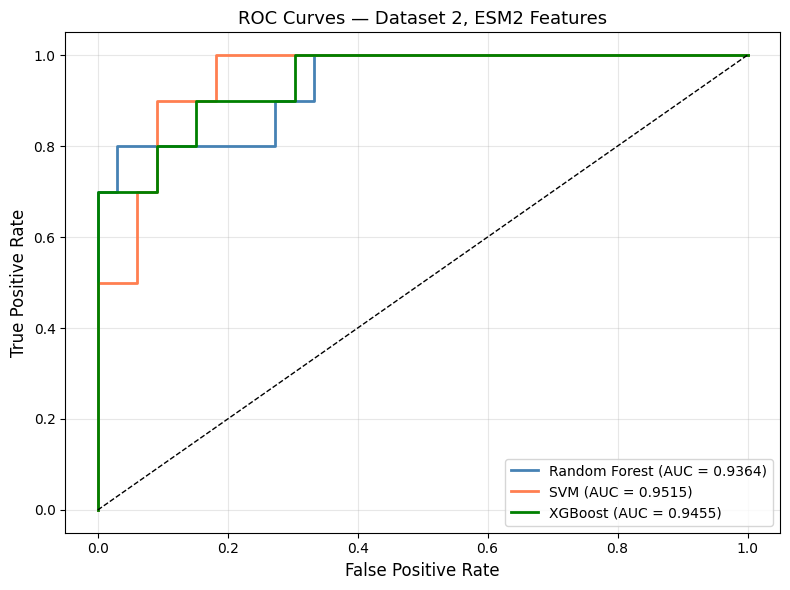

ROC Dataset 2 ESM2 saved ✓


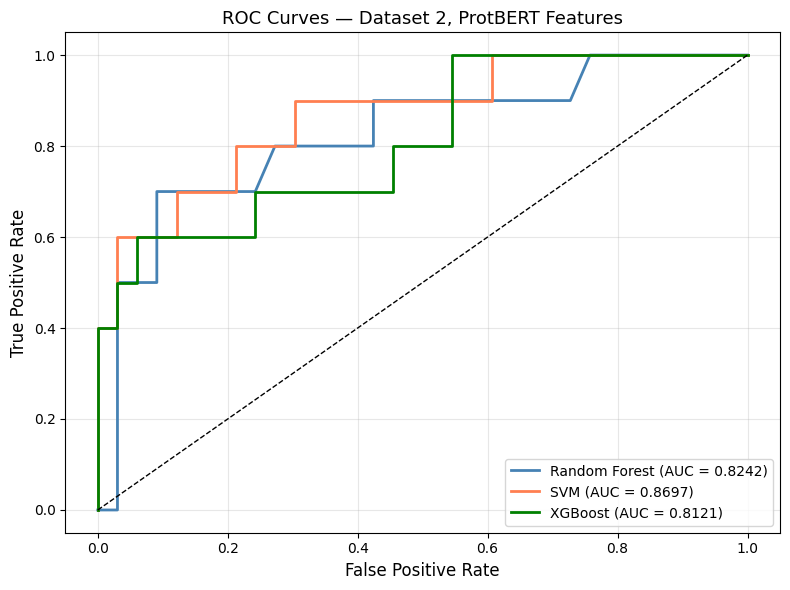

ROC Dataset 2 ProtBERT saved ✓


In [124]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import train_test_split

# ============================================
# Features load karo
# ============================================
X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")
X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
X_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
y_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

X_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_features.npy")
y_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_labels.npy")
X_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_features.npy")
y_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_labels.npy")

X_train_esm2, X_test_esm2, y_train_esm2, y_test_esm2 = train_test_split(
    X_esm2, y_esm2, test_size=0.2, random_state=42, stratify=y_esm2)
X_train_pb2, X_test_pb2, y_train_pb2, y_test_pb2 = train_test_split(
    X_pb2, y_pb2, test_size=0.2, random_state=42, stratify=y_pb2)

# ============================================
# Models
# ============================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
    "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
}

colors = {
    "Random Forest": "steelblue",
    "SVM":           "coral",
    "XGBoost":       "green"
}

# ============================================
# ROC — Dataset 1 ESM2
# ============================================
plt.figure(figsize=(8, 6))
for mname, model in models.items():
    model.fit(X_train_esm, y_train_esm)
    y_prob = model.predict_proba(X_test_esm)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_esm, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[mname], lw=2,
             label=f'{mname} (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Dataset 1, ESM2 Features', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/ROC_D1_ESM2.jpg", dpi=300)
plt.show()
print("ROC Dataset 1 ESM2 saved ✓")

# ============================================
# ROC — Dataset 1 ProtBERT
# ============================================
plt.figure(figsize=(8, 6))
for mname, model in models.items():
    model.fit(X_train_pb, y_train_pb)
    y_prob = model.predict_proba(X_test_pb)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_pb, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[mname], lw=2,
             label=f'{mname} (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Dataset 1, ProtBERT Features', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/ROC_D1_ProtBERT.jpg", dpi=300)
plt.show()
print("ROC Dataset 1 ProtBERT saved ✓")

# ============================================
# ROC — Dataset 2 ESM2
# ============================================
plt.figure(figsize=(8, 6))
for mname, model in models.items():
    model.fit(X_train_esm2, y_train_esm2)
    y_prob = model.predict_proba(X_test_esm2)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_esm2, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[mname], lw=2,
             label=f'{mname} (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Dataset 2, ESM2 Features', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/BetaLactamase_Dataset/ROC_D2_ESM2.jpg", dpi=300)
plt.show()
print("ROC Dataset 2 ESM2 saved ✓")

# ============================================
# ROC — Dataset 2 ProtBERT
# ============================================
plt.figure(figsize=(8, 6))
for mname, model in models.items():
    model.fit(X_train_pb2, y_train_pb2)
    y_prob = model.predict_proba(X_test_pb2)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_pb2, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[mname], lw=2,
             label=f'{mname} (AUC = {roc_auc:.4f})')

plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — Dataset 2, ProtBERT Features', fontsize=13)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/BetaLactamase_Dataset/ROC_D2_ProtBERT.jpg", dpi=300)
plt.show()
print("ROC Dataset 2 ProtBERT saved ✓")

**PR Curve with F1**

Mounted at /content/drive


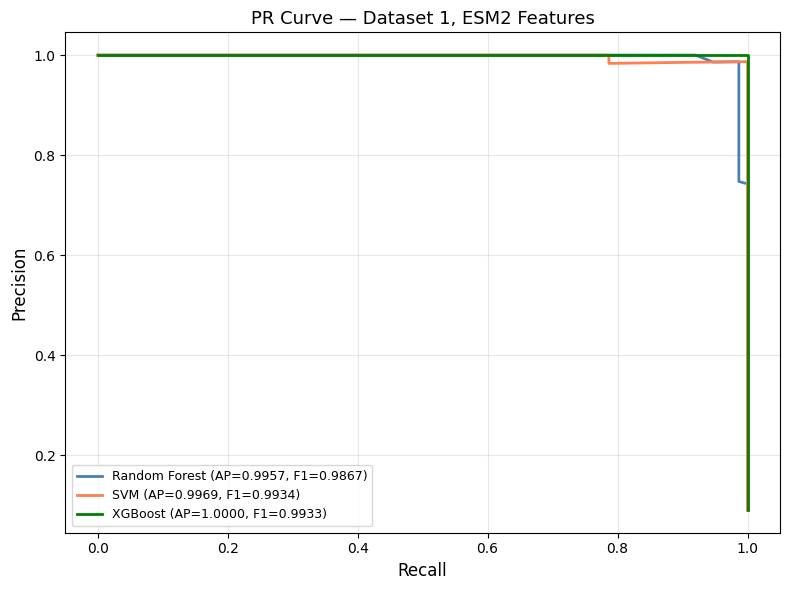

Saved: /content/drive/My Drive/Dataset1_BlaPred/PR_D1_ESM2.jpg ✓


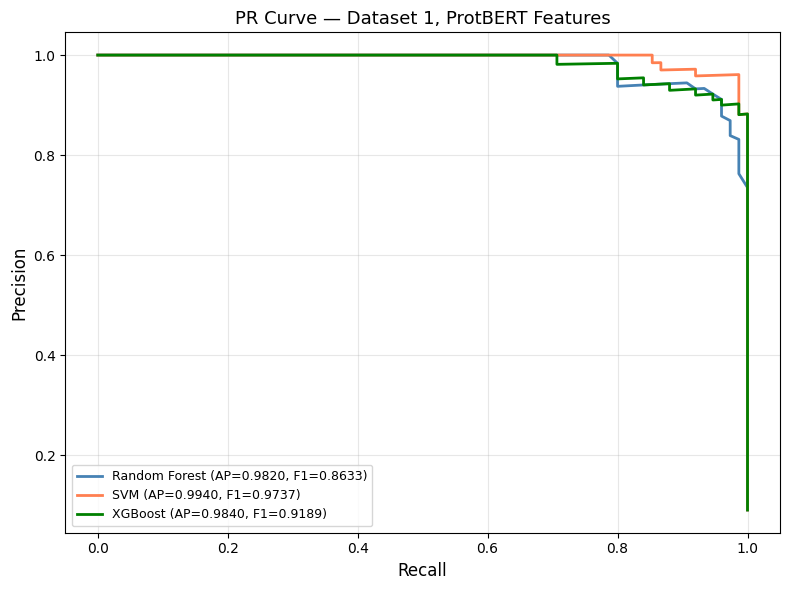

Saved: /content/drive/My Drive/Dataset1_BlaPred/PR_D1_ProtBERT.jpg ✓


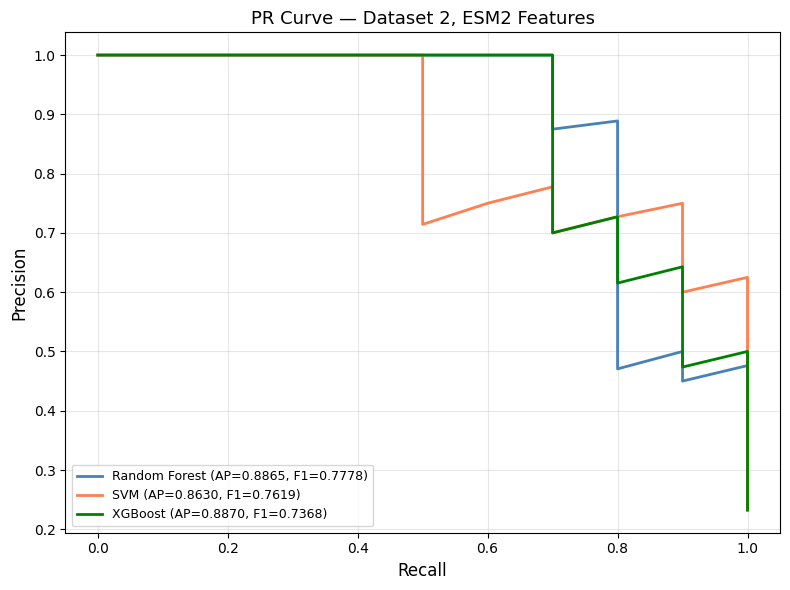

Saved: /content/drive/My Drive/BetaLactamase_Dataset/PR_D2_ESM2.jpg ✓


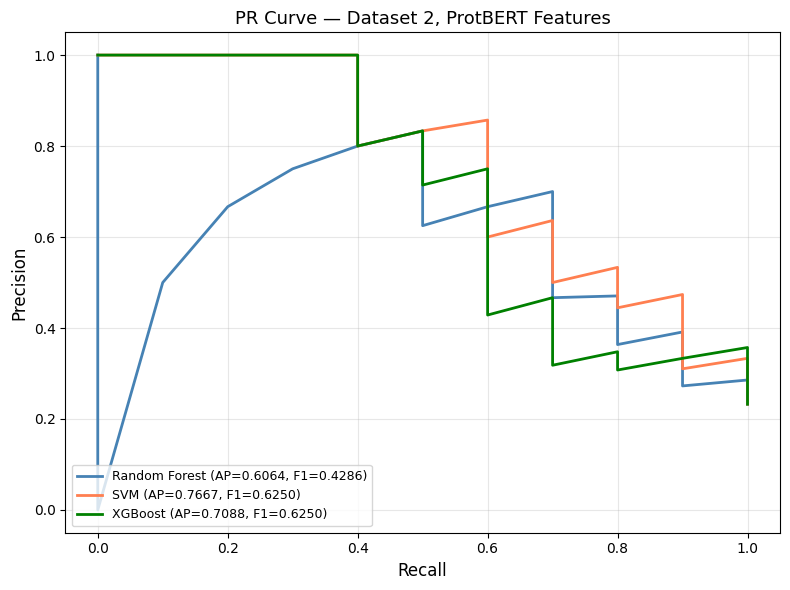

Saved: /content/drive/My Drive/BetaLactamase_Dataset/PR_D2_ProtBERT.jpg ✓


In [125]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
from sklearn.model_selection import train_test_split

# ============================================
# Features load karo
# ============================================
X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")
X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
X_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
y_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

X_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_features.npy")
y_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_labels.npy")
X_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_features.npy")
y_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_labels.npy")

X_train_esm2, X_test_esm2, y_train_esm2, y_test_esm2 = train_test_split(
    X_esm2, y_esm2, test_size=0.2, random_state=42, stratify=y_esm2)
X_train_pb2, X_test_pb2, y_train_pb2, y_test_pb2 = train_test_split(
    X_pb2, y_pb2, test_size=0.2, random_state=42, stratify=y_pb2)

# ============================================
# Models + Colors
# ============================================
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
    "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
}

colors = {
    "Random Forest": "steelblue",
    "SVM":           "coral",
    "XGBoost":       "green"
}

# ============================================
# Function — PR Curve plot karo
# ============================================
def plot_pr_curve(X_train, y_train, X_test, y_test, title, save_path):
    plt.figure(figsize=(8, 6))
    for mname, model in models.items():
        model.fit(X_train, y_train)
        y_prob = model.predict_proba(X_test)[:, 1]
        y_pred = model.predict(X_test)

        precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
        ap = average_precision_score(y_test, y_prob)
        f1 = f1_score(y_test, y_pred)

        plt.plot(recall, precision,
                 color=colors[mname], lw=2,
                 label=f'{mname} (AP={ap:.4f}, F1={f1:.4f})')

    plt.xlabel('Recall', fontsize=12)
    plt.ylabel('Precision', fontsize=12)
    plt.title(title, fontsize=13)
    plt.legend(loc='lower left', fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path} ✓")

# ============================================
# PR Curve — Dataset 1 ESM2
# ============================================
plot_pr_curve(
    X_train_esm, y_train_esm,
    X_test_esm,  y_test_esm,
    title="PR Curve — Dataset 1, ESM2 Features",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/PR_D1_ESM2.jpg"
)

# ============================================
# PR Curve — Dataset 1 ProtBERT
# ============================================
plot_pr_curve(
    X_train_pb, y_train_pb,
    X_test_pb,  y_test_pb,
    title="PR Curve — Dataset 1, ProtBERT Features",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/PR_D1_ProtBERT.jpg"
)

# ============================================
# PR Curve — Dataset 2 ESM2
# ============================================
plot_pr_curve(
    X_train_esm2, y_train_esm2,
    X_test_esm2,  y_test_esm2,
    title="PR Curve — Dataset 2, ESM2 Features",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/PR_D2_ESM2.jpg"
)

# ============================================
# PR Curve — Dataset 2 ProtBERT
# ============================================
plot_pr_curve(
    X_train_pb2, y_train_pb2,
    X_test_pb2,  y_test_pb2,
    title="PR Curve — Dataset 2, ProtBERT Features",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/PR_D2_ProtBERT.jpg"
)

**Feature Importance**

Mounted at /content/drive


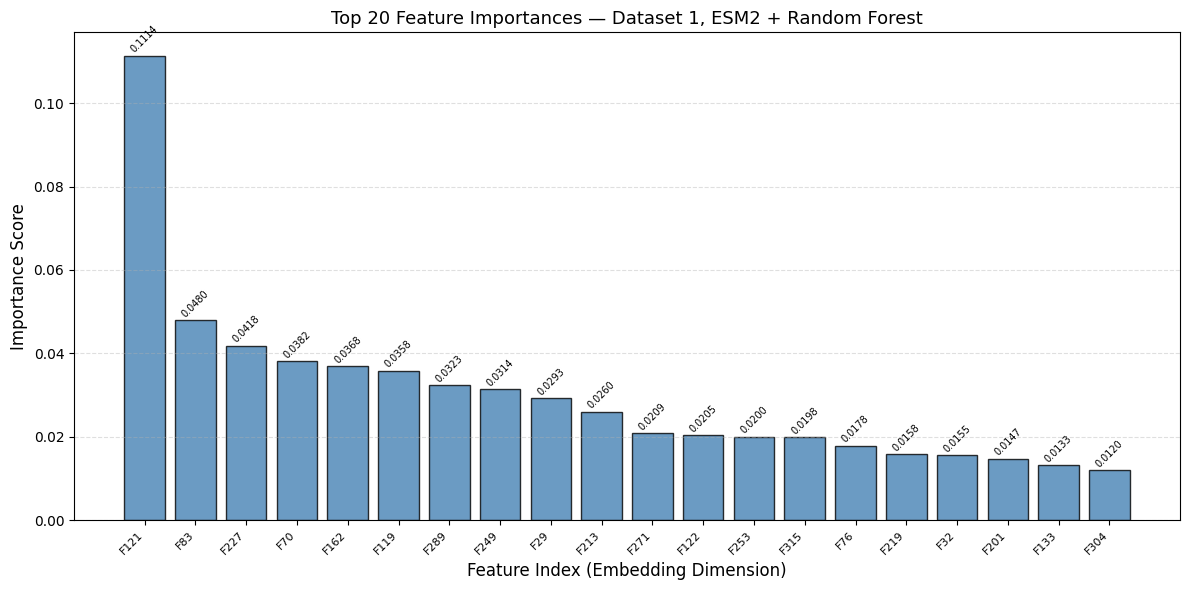

Saved: /content/drive/My Drive/Dataset1_BlaPred/FI_D1_ESM2_RF.jpg ✓


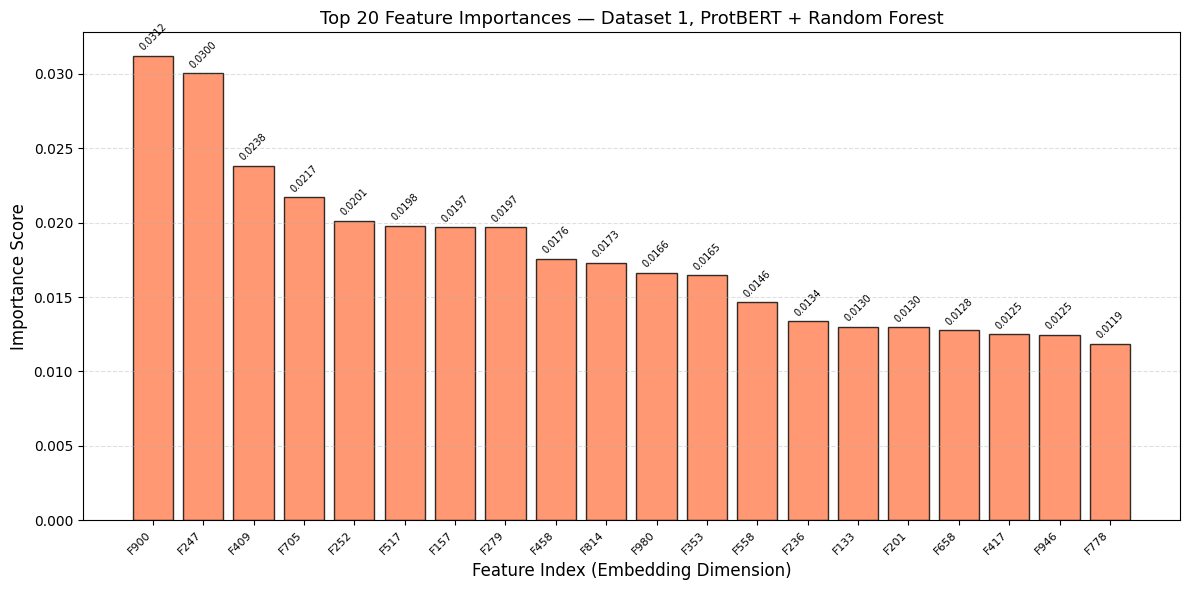

Saved: /content/drive/My Drive/Dataset1_BlaPred/FI_D1_PB_RF.jpg ✓


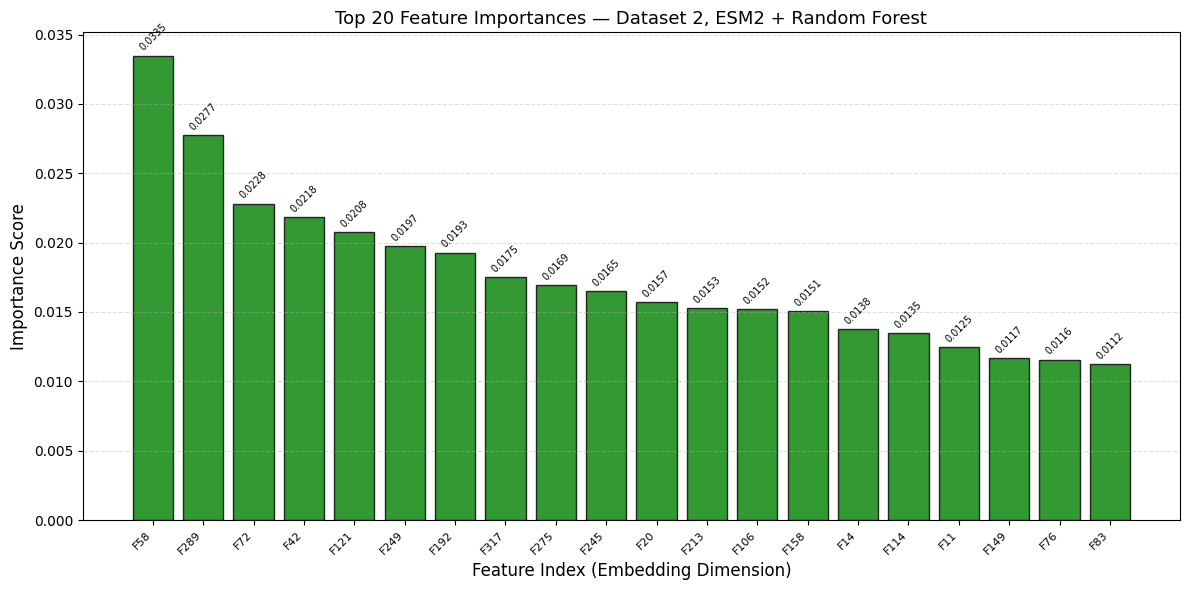

Saved: /content/drive/My Drive/BetaLactamase_Dataset/FI_D2_ESM2_RF.jpg ✓


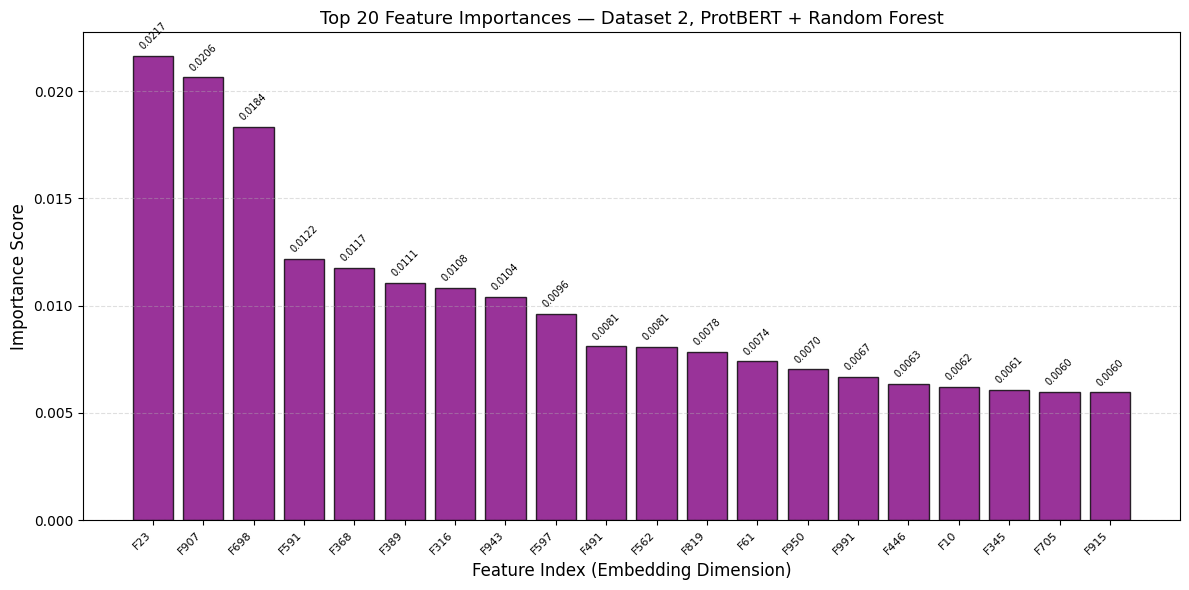

Saved: /content/drive/My Drive/BetaLactamase_Dataset/FI_D2_PB_RF.jpg ✓


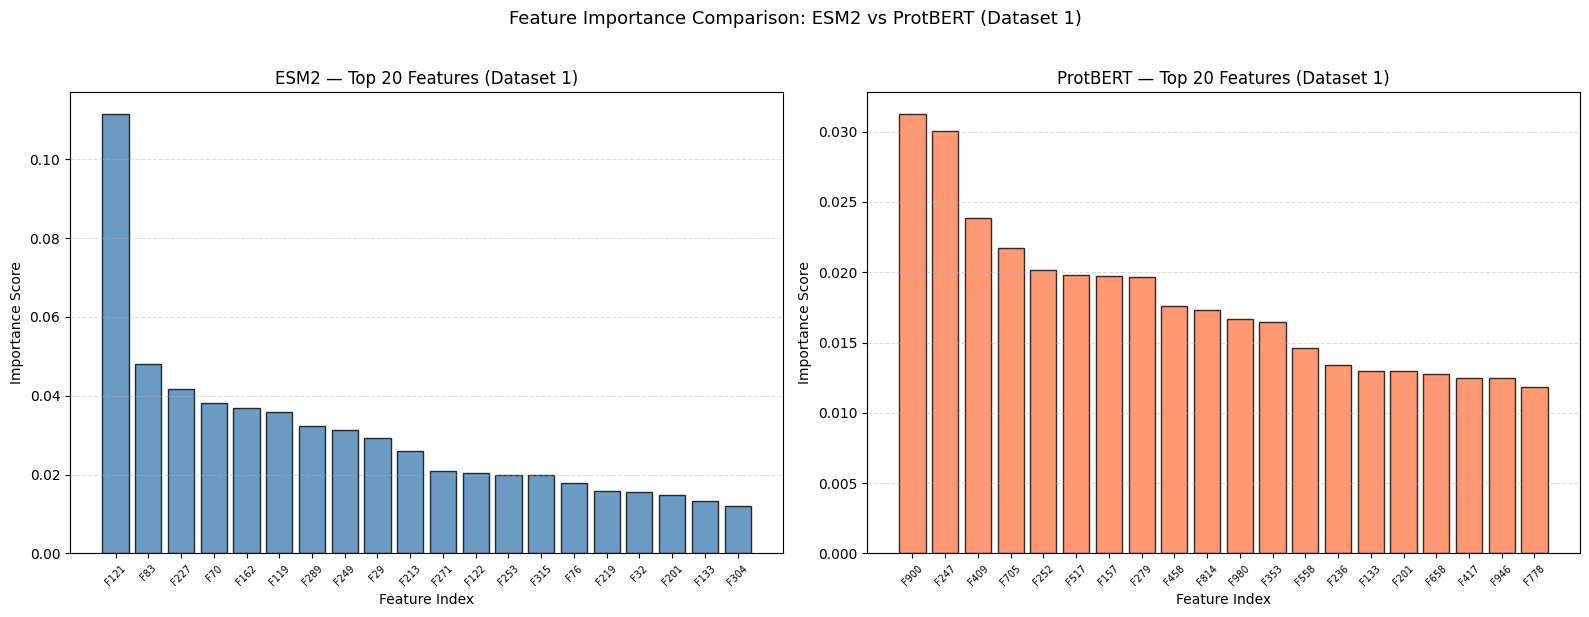

Comparison plot saved ✓


In [126]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split

# ============================================
# Features load karo
# ============================================
X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")

X_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_features.npy")
y_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_labels.npy")
X_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_features.npy")
y_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_labels.npy")

X_train_esm2, _, y_train_esm2, _ = train_test_split(
    X_esm2, y_esm2, test_size=0.2, random_state=42, stratify=y_esm2)
X_train_pb2, _, y_train_pb2, _ = train_test_split(
    X_pb2, y_pb2, test_size=0.2, random_state=42, stratify=y_pb2)

# ============================================
# Function — Feature Importance Plot
# ============================================
def plot_feature_importance(X_train, y_train, title, save_path,
                             top_n=20, color='steelblue'):
    # Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)

    importances = rf.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    top_importances = importances[indices]
    top_indices = indices

    plt.figure(figsize=(12, 6))
    bars = plt.bar(range(top_n), top_importances,
                   color=color, edgecolor='black', alpha=0.8)

    # Values upar dikhao
    for i, bar in enumerate(bars):
        plt.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.0002,
                 f'{bar.get_height():.4f}',
                 ha='center', va='bottom', fontsize=7, rotation=45)

    plt.xlabel('Feature Index (Embedding Dimension)', fontsize=12)
    plt.ylabel('Importance Score', fontsize=12)
    plt.title(title, fontsize=13)
    plt.xticks(range(top_n),
               [f'F{idx}' for idx in top_indices],
               rotation=45, ha='right', fontsize=8)
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path} ✓")

# ============================================
# Plot 1 — Dataset 1, ESM2 + RF
# ============================================
plot_feature_importance(
    X_train_esm, y_train_esm,
    title="Top 20 Feature Importances — Dataset 1, ESM2 + Random Forest",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/FI_D1_ESM2_RF.jpg",
    color='steelblue'
)

# ============================================
# Plot 2 — Dataset 1, ProtBERT + RF
# ============================================
plot_feature_importance(
    X_train_pb, y_train_pb,
    title="Top 20 Feature Importances — Dataset 1, ProtBERT + Random Forest",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/FI_D1_PB_RF.jpg",
    color='coral'
)

# ============================================
# Plot 3 — Dataset 2, ESM2 + RF
# ============================================
plot_feature_importance(
    X_train_esm2, y_train_esm2,
    title="Top 20 Feature Importances — Dataset 2, ESM2 + Random Forest",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/FI_D2_ESM2_RF.jpg",
    color='green'
)

# ============================================
# Plot 4 — Dataset 2, ProtBERT + RF
# ============================================
plot_feature_importance(
    X_train_pb2, y_train_pb2,
    title="Top 20 Feature Importances — Dataset 2, ProtBERT + Random Forest",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/FI_D2_PB_RF.jpg",
    color='purple'
)

# ============================================
# Plot 5 — ESM2 vs ProtBERT Combined Comparison
# ============================================
rf_esm = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pb  = RandomForestClassifier(n_estimators=100, random_state=42)
rf_esm.fit(X_train_esm, y_train_esm)
rf_pb.fit(X_train_pb,  y_train_pb)

top_n = 20
idx_esm = np.argsort(rf_esm.feature_importances_)[::-1][:top_n]
idx_pb  = np.argsort(rf_pb.feature_importances_)[::-1][:top_n]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.bar(range(top_n), rf_esm.feature_importances_[idx_esm],
        color='steelblue', edgecolor='black', alpha=0.8)
ax1.set_title('ESM2 — Top 20 Features (Dataset 1)', fontsize=12)
ax1.set_xlabel('Feature Index', fontsize=10)
ax1.set_ylabel('Importance Score', fontsize=10)
ax1.set_xticks(range(top_n))
ax1.set_xticklabels([f'F{i}' for i in idx_esm], rotation=45, fontsize=7)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

ax2.bar(range(top_n), rf_pb.feature_importances_[idx_pb],
        color='coral', edgecolor='black', alpha=0.8)
ax2.set_title('ProtBERT — Top 20 Features (Dataset 1)', fontsize=12)
ax2.set_xlabel('Feature Index', fontsize=10)
ax2.set_ylabel('Importance Score', fontsize=10)
ax2.set_xticks(range(top_n))
ax2.set_xticklabels([f'F{i}' for i in idx_pb], rotation=45, fontsize=7)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle('Feature Importance Comparison: ESM2 vs ProtBERT (Dataset 1)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/FI_Comparison.jpg",
            dpi=300, bbox_inches='tight')
plt.show()
print("Comparison plot saved ✓")

**Feature Boundary**

Mounted at /content/drive
PCA chal raha hai: PCA Feature Boundary — Dataset 1, ESM2 Embeddings


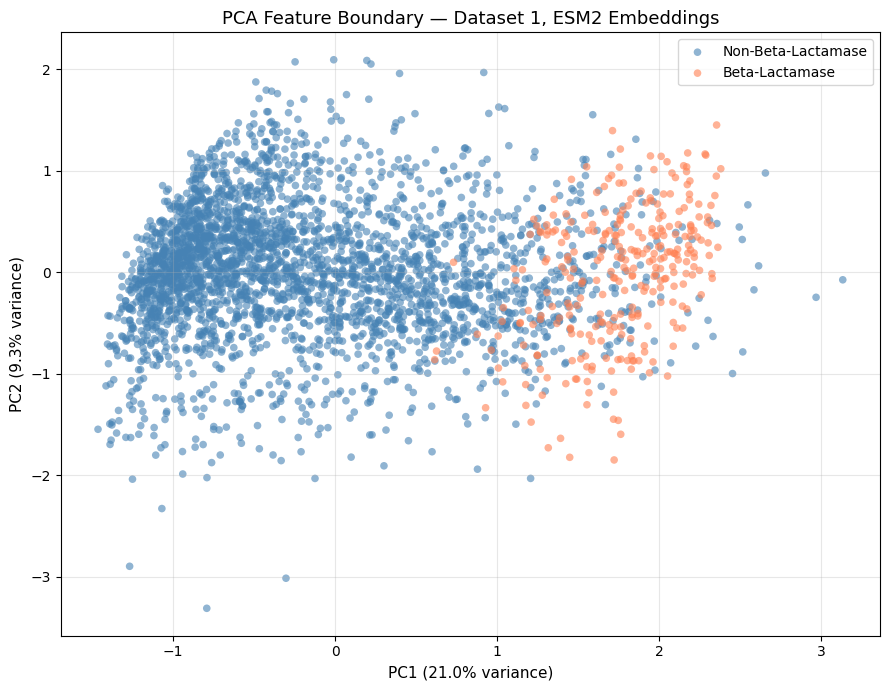

Saved: /content/drive/My Drive/Dataset1_BlaPred/PCA_D1_ESM2.jpg ✓
PCA chal raha hai: PCA Feature Boundary — Dataset 1, ProtBERT Embeddings


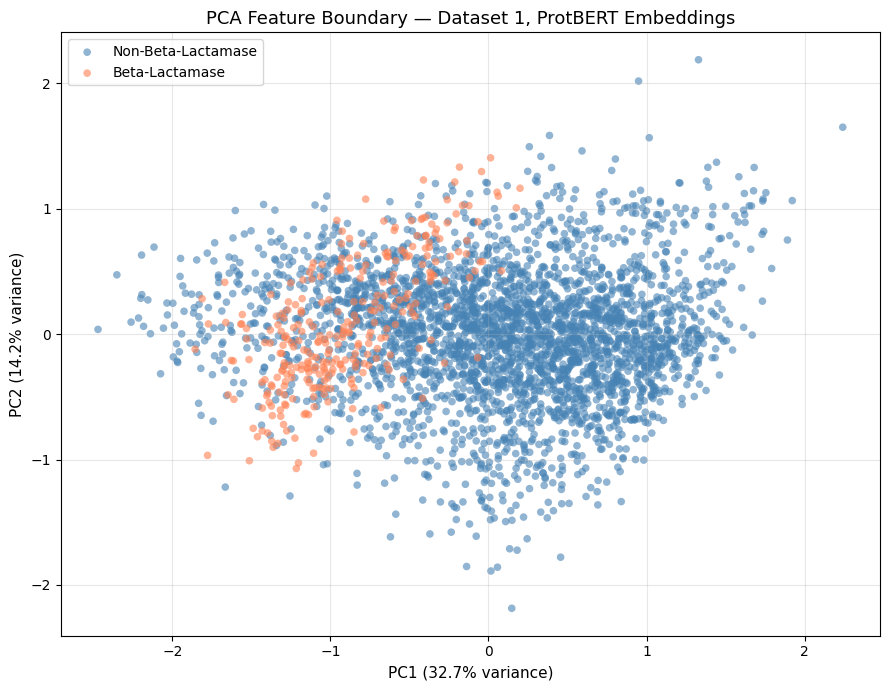

Saved: /content/drive/My Drive/Dataset1_BlaPred/PCA_D1_ProtBERT.jpg ✓
PCA chal raha hai: PCA Feature Boundary — Dataset 2, ESM2 Embeddings


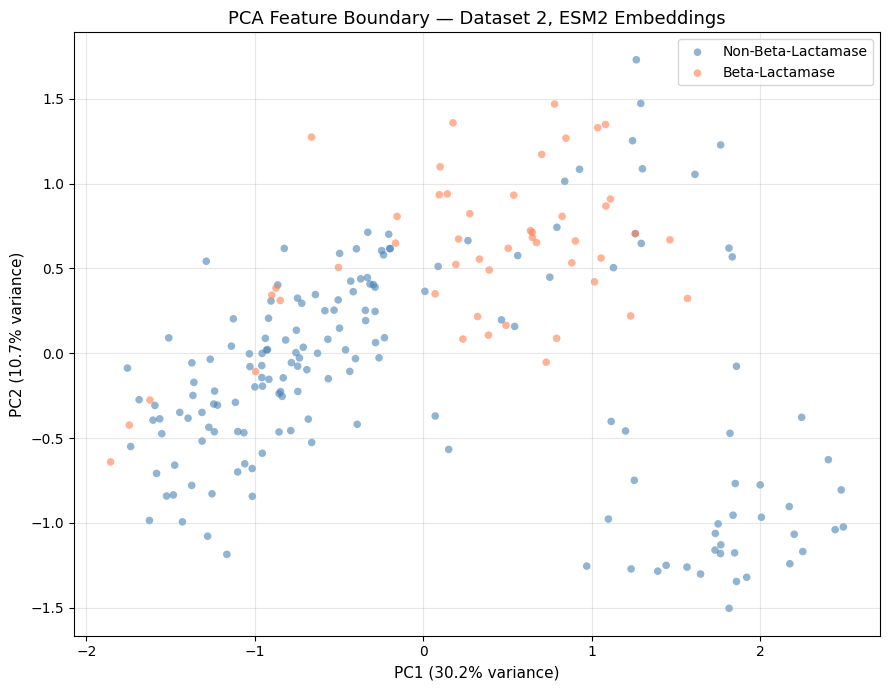

Saved: /content/drive/My Drive/BetaLactamase_Dataset/PCA_D2_ESM2.jpg ✓
PCA chal raha hai: PCA Feature Boundary — Dataset 2, ProtBERT Embeddings


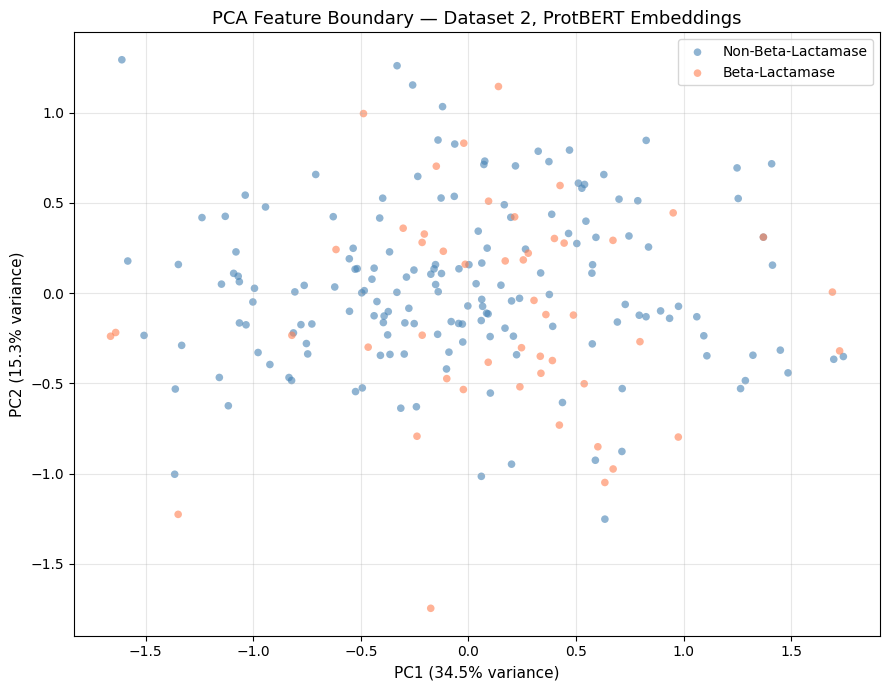

Saved: /content/drive/My Drive/BetaLactamase_Dataset/PCA_D2_ProtBERT.jpg ✓
t-SNE chal raha hai: t-SNE Feature Boundary — Dataset 1, ESM2 Embeddings (time lagega...)


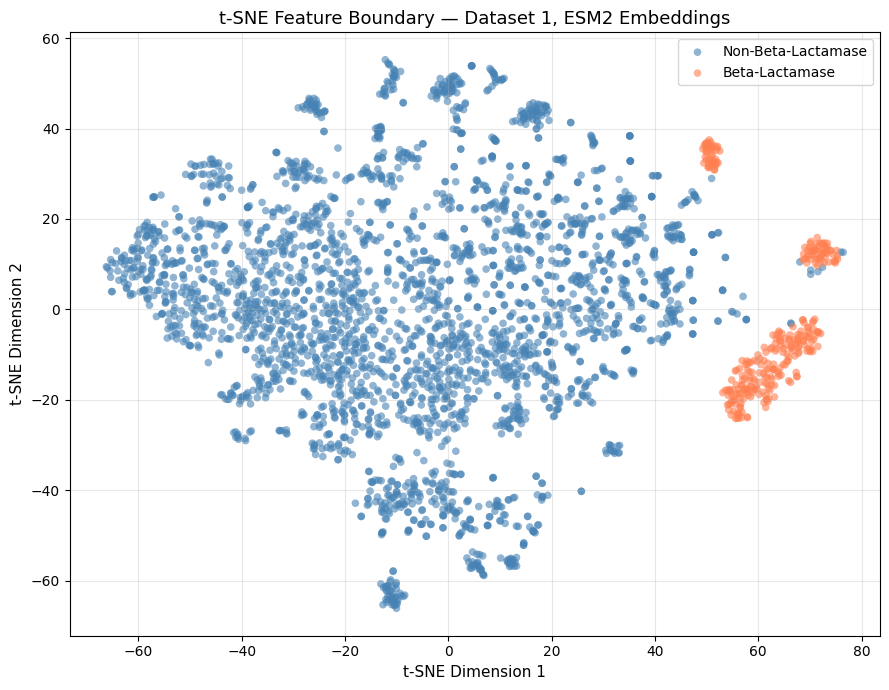

Saved: /content/drive/My Drive/Dataset1_BlaPred/tSNE_D1_ESM2.jpg ✓
t-SNE chal raha hai: t-SNE Feature Boundary — Dataset 1, ProtBERT Embeddings (time lagega...)


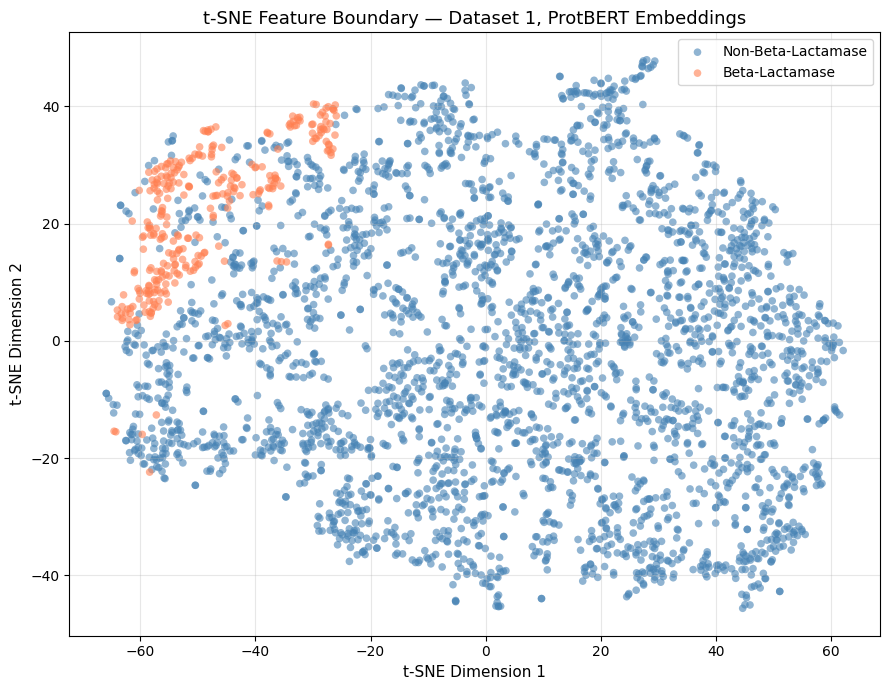

Saved: /content/drive/My Drive/Dataset1_BlaPred/tSNE_D1_ProtBERT.jpg ✓
t-SNE chal raha hai: t-SNE Feature Boundary — Dataset 2, ESM2 Embeddings (time lagega...)


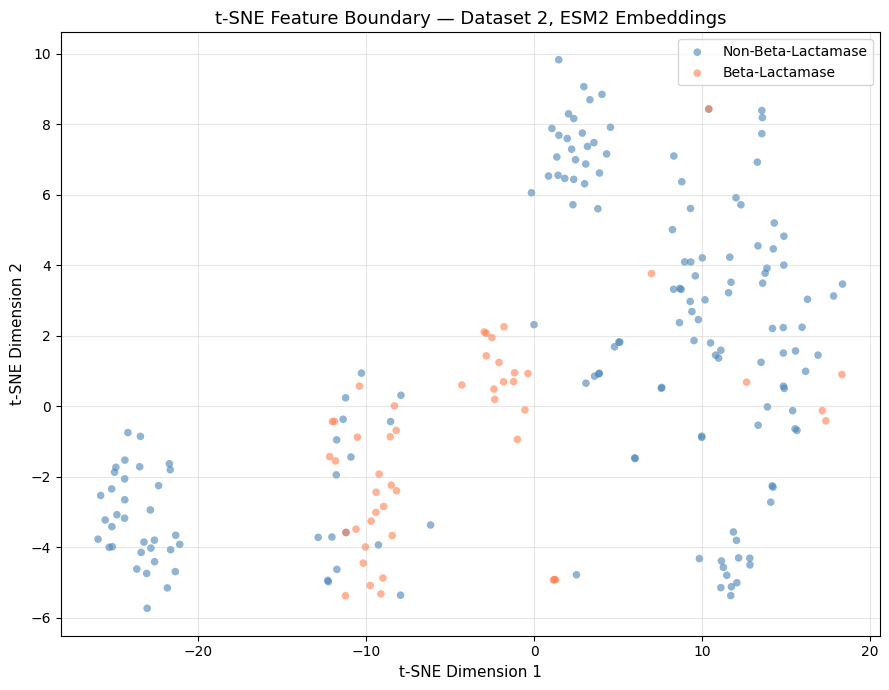

Saved: /content/drive/My Drive/BetaLactamase_Dataset/tSNE_D2_ESM2.jpg ✓
t-SNE chal raha hai: t-SNE Feature Boundary — Dataset 2, ProtBERT Embeddings (time lagega...)


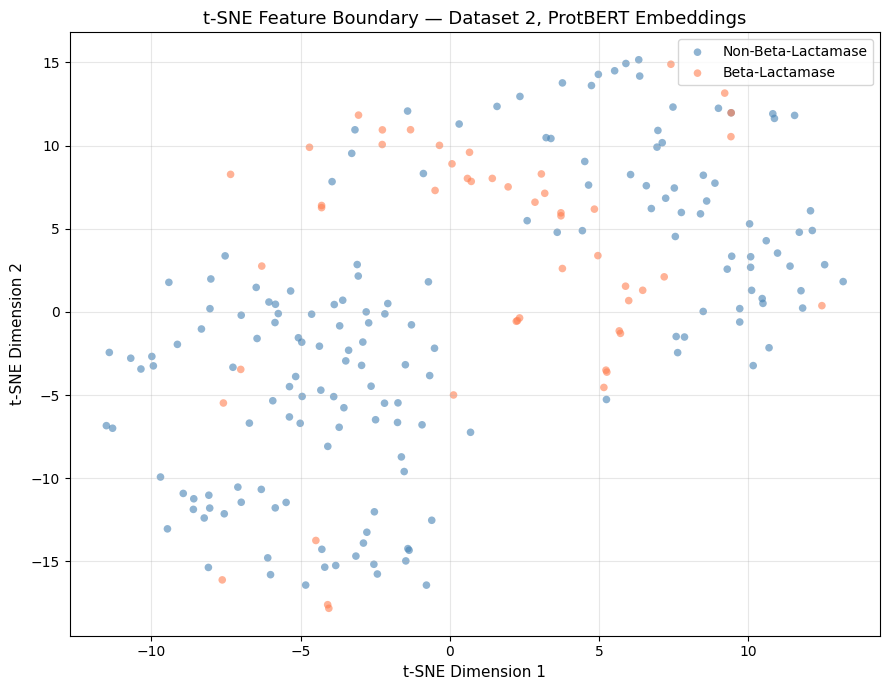

Saved: /content/drive/My Drive/BetaLactamase_Dataset/tSNE_D2_ProtBERT.jpg ✓


In [127]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

# ============================================
# Features load karo
# ============================================
X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")
X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
X_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
y_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

X_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_features.npy")
y_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_labels.npy")
X_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_features.npy")
y_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_labels.npy")

# Combine train + test Dataset 1
X_all_esm = np.concatenate([X_train_esm, X_test_esm])
y_all_esm = np.concatenate([y_train_esm, y_test_esm])
X_all_pb  = np.concatenate([X_train_pb,  X_test_pb])
y_all_pb  = np.concatenate([y_train_pb,  y_test_pb])

# Colors
colors = {0: 'steelblue', 1: 'coral'}
labels = {0: 'Non-Beta-Lactamase', 1: 'Beta-Lactamase'}

# ============================================
# Function — PCA Plot
# ============================================
def plot_pca(X, y, title, save_path):
    print(f"PCA chal raha hai: {title}")
    pca = PCA(n_components=2, random_state=42)
    X_pca = pca.fit_transform(X)

    plt.figure(figsize=(9, 7))
    for label in [0, 1]:
        mask = y == label
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=colors[label],
                   label=labels[label],
                   alpha=0.6, s=30, edgecolors='none')

    plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=11)
    plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=11)
    plt.title(title, fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path} ✓")

# ============================================
# Function — t-SNE Plot
# ============================================
def plot_tsne(X, y, title, save_path):
    print(f"t-SNE chal raha hai: {title} (time lagega...)")
    tsne = TSNE(n_components=2, random_state=42,
                perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X)

    plt.figure(figsize=(9, 7))
    for label in [0, 1]:
        mask = y == label
        plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                   c=colors[label],
                   label=labels[label],
                   alpha=0.6, s=30, edgecolors='none')

    plt.xlabel('t-SNE Dimension 1', fontsize=11)
    plt.ylabel('t-SNE Dimension 2', fontsize=11)
    plt.title(title, fontsize=13)
    plt.legend(fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved: {save_path} ✓")

# ============================================
# PCA Plots — Dataset 1
# ============================================
plot_pca(
    X_all_esm, y_all_esm,
    title="PCA Feature Boundary — Dataset 1, ESM2 Embeddings",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/PCA_D1_ESM2.jpg"
)

plot_pca(
    X_all_pb, y_all_pb,
    title="PCA Feature Boundary — Dataset 1, ProtBERT Embeddings",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/PCA_D1_ProtBERT.jpg"
)

# ============================================
# PCA Plots — Dataset 2
# ============================================
plot_pca(
    X_esm2, y_esm2,
    title="PCA Feature Boundary — Dataset 2, ESM2 Embeddings",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/PCA_D2_ESM2.jpg"
)

plot_pca(
    X_pb2, y_pb2,
    title="PCA Feature Boundary — Dataset 2, ProtBERT Embeddings",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/PCA_D2_ProtBERT.jpg"
)

# ============================================
# t-SNE Plots — Dataset 1
# ============================================
plot_tsne(
    X_all_esm, y_all_esm,
    title="t-SNE Feature Boundary — Dataset 1, ESM2 Embeddings",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/tSNE_D1_ESM2.jpg"
)

plot_tsne(
    X_all_pb, y_all_pb,
    title="t-SNE Feature Boundary — Dataset 1, ProtBERT Embeddings",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/tSNE_D1_ProtBERT.jpg"
)

# ============================================
# t-SNE Plots — Dataset 2
# ============================================
plot_tsne(
    X_esm2, y_esm2,
    title="t-SNE Feature Boundary — Dataset 2, ESM2 Embeddings",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/tSNE_D2_ESM2.jpg"
)

plot_tsne(
    X_pb2, y_pb2,
    title="t-SNE Feature Boundary — Dataset 2, ProtBERT Embeddings",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/tSNE_D2_ProtBERT.jpg"
)

**Decision Boundary**

Mounted at /content/drive
PCA reducing: Decision Boundary — Dataset 1, ESM2 Features (PCA 2D)
  Training Random Forest...
  Training SVM...
  Training XGBoost...


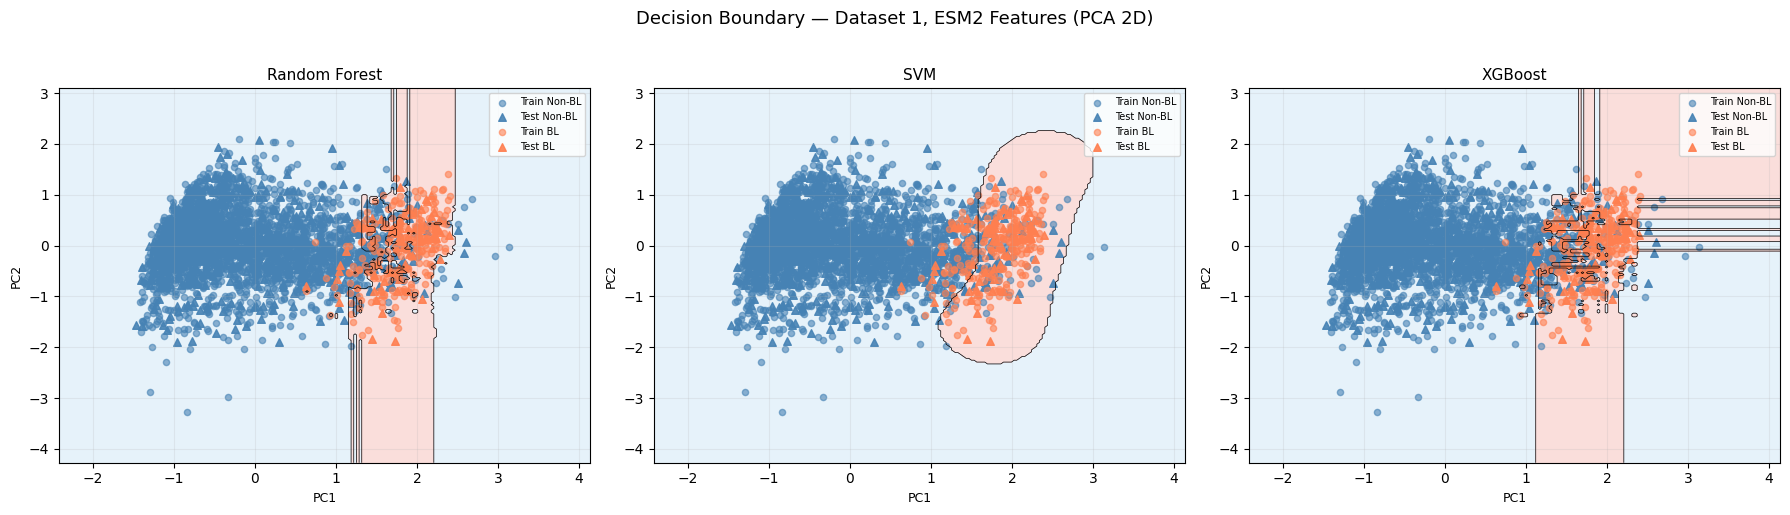

Saved: /content/drive/My Drive/Dataset1_BlaPred/DB_D1_ESM2.jpg ✓

PCA reducing: Decision Boundary — Dataset 1, ProtBERT Features (PCA 2D)
  Training Random Forest...
  Training SVM...
  Training XGBoost...


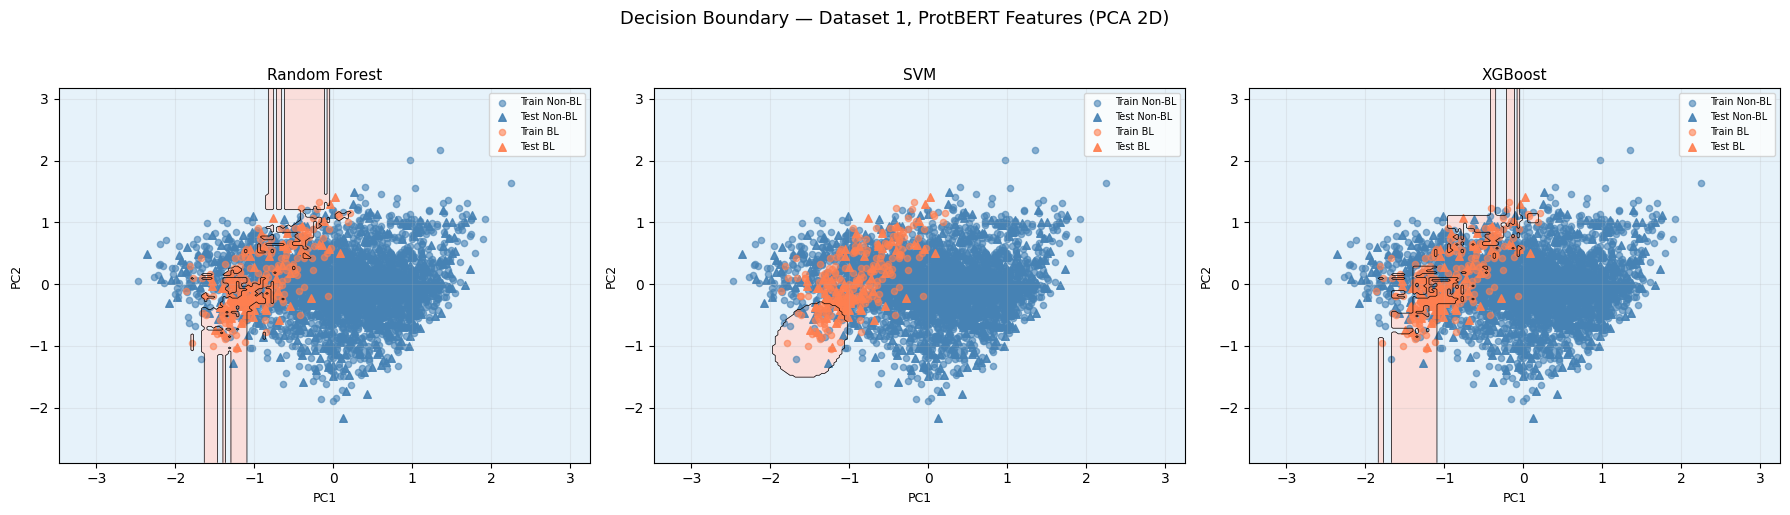

Saved: /content/drive/My Drive/Dataset1_BlaPred/DB_D1_ProtBERT.jpg ✓

PCA reducing: Decision Boundary — Dataset 2, ESM2 Features (PCA 2D)
  Training Random Forest...
  Training SVM...
  Training XGBoost...


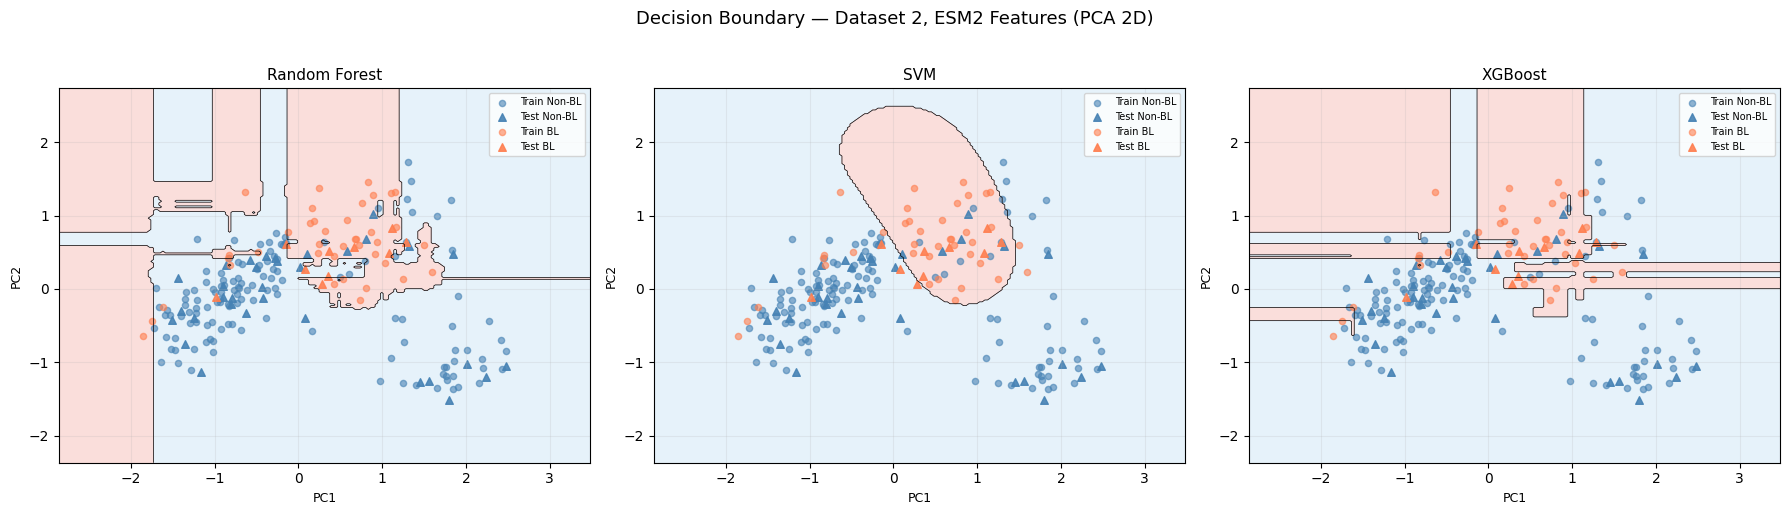

Saved: /content/drive/My Drive/BetaLactamase_Dataset/DB_D2_ESM2.jpg ✓

PCA reducing: Decision Boundary — Dataset 2, ProtBERT Features (PCA 2D)
  Training Random Forest...
  Training SVM...
  Training XGBoost...


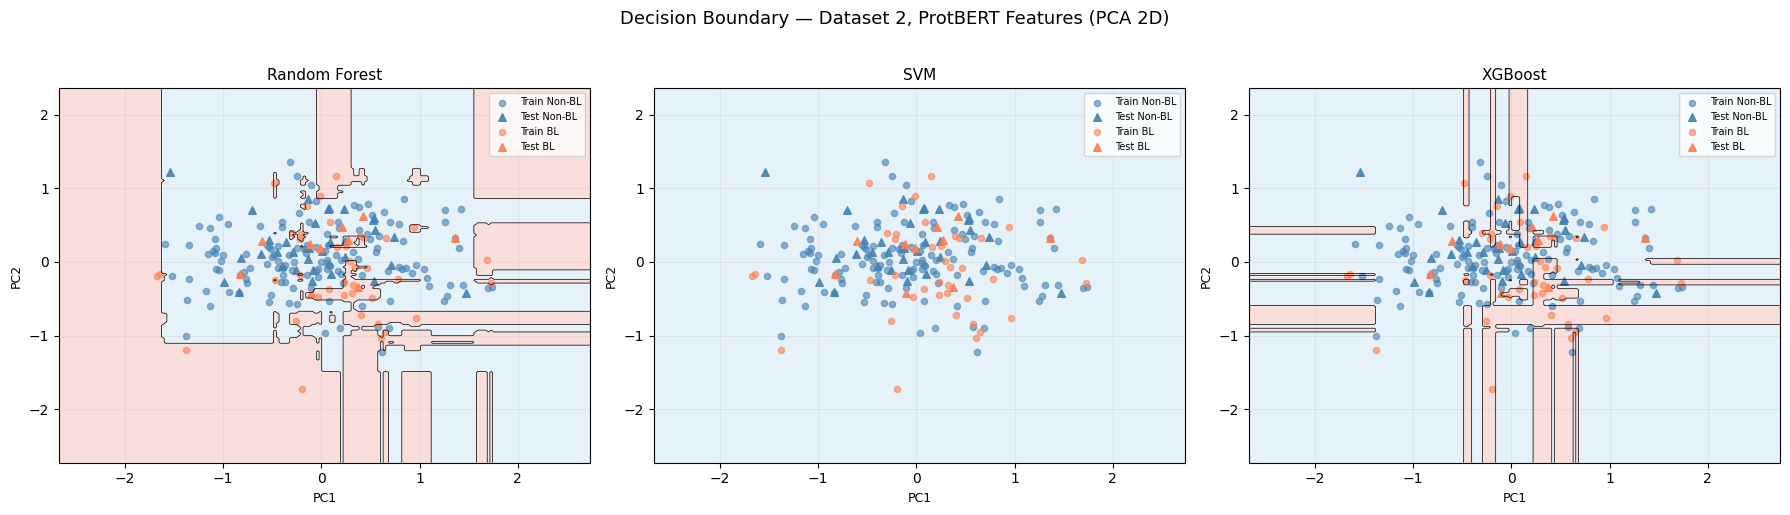

Saved: /content/drive/My Drive/BetaLactamase_Dataset/DB_D2_ProtBERT.jpg ✓



In [128]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ============================================
# Features load karo
# ============================================
X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")
X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
X_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
y_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

X_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_features.npy")
y_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_labels.npy")
X_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_features.npy")
y_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_labels.npy")

# Combine Dataset 1
X_all_esm = np.concatenate([X_train_esm, X_test_esm])
y_all_esm = np.concatenate([y_train_esm, y_test_esm])
X_all_pb  = np.concatenate([X_train_pb,  X_test_pb])
y_all_pb  = np.concatenate([y_train_pb,  y_test_pb])

# Dataset 2 split
X_tr_esm2, X_te_esm2, y_tr_esm2, y_te_esm2 = train_test_split(
    X_esm2, y_esm2, test_size=0.2, random_state=42, stratify=y_esm2)
X_tr_pb2, X_te_pb2, y_tr_pb2, y_te_pb2 = train_test_split(
    X_pb2, y_pb2, test_size=0.2, random_state=42, stratify=y_pb2)

# ============================================
# Function — Decision Boundary
# ============================================
def plot_decision_boundary(X_train, y_train, X_test, y_test,
                            title, save_path):
    # PCA se 2D reduce karo
    print(f"PCA reducing: {title}")
    pca = PCA(n_components=2, random_state=42)
    X_train_2d = pca.fit_transform(X_train)
    X_test_2d  = pca.transform(X_test)

    models = {
        "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
        "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
        "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
    }

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(title, fontsize=13, y=1.02)

    colors_bg = ['#AED6F1', '#F1948A']  # background colors
    colors_pt = ['steelblue', 'coral']   # point colors

    for ax, (mname, model) in zip(axes, models.items()):
        print(f"  Training {mname}...")
        model.fit(X_train_2d, y_train)

        # Mesh grid banao
        x_min = X_train_2d[:, 0].min() - 1
        x_max = X_train_2d[:, 0].max() + 1
        y_min = X_train_2d[:, 1].min() - 1
        y_max = X_train_2d[:, 1].max() + 1

        xx, yy = np.meshgrid(
            np.linspace(x_min, x_max, 200),
            np.linspace(y_min, y_max, 200)
        )

        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Background color
        ax.contourf(xx, yy, Z, alpha=0.3,
                   colors=colors_bg, levels=[-0.5, 0.5, 1.5])
        ax.contour(xx, yy, Z, colors='black',
                  linewidths=0.5, levels=[0.5])

        # Data points
        for label, color in zip([0, 1], colors_pt):
            mask_train = y_train == label
            mask_test  = y_test  == label
            ax.scatter(X_train_2d[mask_train, 0],
                      X_train_2d[mask_train, 1],
                      c=color, marker='o', s=20,
                      alpha=0.6, label=f'Train {"BL" if label==1 else "Non-BL"}')
            ax.scatter(X_test_2d[mask_test, 0],
                      X_test_2d[mask_test, 1],
                      c=color, marker='^', s=30,
                      alpha=0.9, label=f'Test {"BL" if label==1 else "Non-BL"}')

        ax.set_title(mname, fontsize=11)
        ax.set_xlabel('PC1', fontsize=9)
        ax.set_ylabel('PC2', fontsize=9)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(alpha=0.2)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path} ✓\n")

# ============================================
# Plot 1 — Dataset 1, ESM2
# ============================================
plot_decision_boundary(
    X_train_esm, y_train_esm,
    X_test_esm,  y_test_esm,
    title="Decision Boundary — Dataset 1, ESM2 Features (PCA 2D)",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/DB_D1_ESM2.jpg"
)

# ============================================
# Plot 2 — Dataset 1, ProtBERT
# ============================================
plot_decision_boundary(
    X_train_pb, y_train_pb,
    X_test_pb,  y_test_pb,
    title="Decision Boundary — Dataset 1, ProtBERT Features (PCA 2D)",
    save_path="/content/drive/My Drive/Dataset1_BlaPred/DB_D1_ProtBERT.jpg"
)

# ============================================
# Plot 3 — Dataset 2, ESM2
# ============================================
plot_decision_boundary(
    X_tr_esm2, y_tr_esm2,
    X_te_esm2, y_te_esm2,
    title="Decision Boundary — Dataset 2, ESM2 Features (PCA 2D)",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/DB_D2_ESM2.jpg"
)

# ============================================
# Plot 4 — Dataset 2, ProtBERT
# ============================================
plot_decision_boundary(
    X_tr_pb2, y_tr_pb2,
    X_te_pb2, y_te_pb2,
    title="Decision Boundary — Dataset 2, ProtBERT Features (PCA 2D)",
    save_path="/content/drive/My Drive/BetaLactamase_Dataset/DB_D2_ProtBERT.jpg"
)

**Githum issue fix**

**Amino Acid Importance**

In [100]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import numpy as np
# import matplotlib.pyplot as plt
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import train_test_split
# from Bio import SeqIO
# import shutil

# # ============================================
# # FASTA files load karo
# # ============================================
# files = [
#     "training_223_beta_lactamase.fasta",
#     "training_negative_2250.fasta",
#     "benchmark_75_beta_lactamase.fasta",
#     "benchmark_750_nonbeta_lactamase.fasta"
# ]

# for f in files:
#     src = f"/content/drive/My Drive/Dataset1_BlaPred/{f}"
#     dst = f"/content/{f}"
#     shutil.copy(src, dst)
#     print(f"Loaded: {f} ✓")

# # ============================================
# # Amino Acid Composition calculate karo
# # ============================================
# amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# def get_aac(fasta_file, label):
#     compositions = []
#     labels = []
#     for record in SeqIO.parse(fasta_file, "fasta"):
#         seq = str(record.seq).upper()
#         total = len(seq)
#         comp = [seq.count(aa)/total*100 for aa in amino_acids]
#         compositions.append(comp)
#         labels.append(label)
#     return compositions, labels

# print("\nComposition calculate ho rahi hai...")
# pos_train, lab_pos = get_aac("/content/training_223_beta_lactamase.fasta", 1)
# neg_train, lab_neg = get_aac("/content/training_negative_2250.fasta", 0)
# pos_test,  lab_pt  = get_aac("/content/benchmark_75_beta_lactamase.fasta", 1)
# neg_test,  lab_nt  = get_aac("/content/benchmark_750_nonbeta_lactamase.fasta", 0)

# X_aac = np.array(pos_train + neg_train + pos_test + neg_test)
# y_aac = np.array(lab_pos  + lab_neg  + lab_pt  + lab_nt)

# print(f"AAC shape: {X_aac.shape}")

# # ============================================
# # Random Forest train karo
# # ============================================
# X_tr, X_te, y_tr, y_te = train_test_split(
#     X_aac, y_aac, test_size=0.2, random_state=42, stratify=y_aac)

# rf = RandomForestClassifier(n_estimators=100, random_state=42)
# rf.fit(X_tr, y_tr)
# print(f"RF Accuracy on AAC: {rf.score(X_te, y_te)*100:.2f}%")

# importances = rf.feature_importances_
# indices = np.argsort(importances)[::-1]

# # ============================================
# # Plot 1 — Bar Chart (All 20 Amino Acids)
# # ============================================
# plt.figure(figsize=(12, 6))
# bars = plt.bar(range(20),
#                importances[indices],
#                color=['steelblue' if importances[indices[i]] >
#                       np.mean(importances) else 'lightsteelblue'
#                       for i in range(20)],
#                edgecolor='black', alpha=0.85)

# for i, bar in enumerate(bars):
#     plt.text(bar.get_x() + bar.get_width()/2,
#              bar.get_height() + 0.0005,
#              f'{importances[indices[i]]:.4f}',
#              ha='center', va='bottom', fontsize=8, rotation=45)

# plt.xticks(range(20),
#            [amino_acids[i] for i in indices],
#            fontsize=11)
# plt.xlabel('Amino Acid', fontsize=12)
# plt.ylabel('Importance Score', fontsize=12)
# plt.title('Amino Acid Importance — Dataset 1 (Random Forest)', fontsize=13)
# plt.axhline(y=np.mean(importances), color='red',
#             linestyle='--', label=f'Mean = {np.mean(importances):.4f}')
# plt.legend(fontsize=10)
# plt.grid(axis='y', linestyle='--', alpha=0.4)
# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/AA_Importance_D1.jpg",
#             dpi=300)
# plt.show()
# print("Plot 1 saved ✓")

# # ============================================
# # Plot 2 — Positive vs Negative Mean Composition
# # ============================================
# pos_data = np.array(pos_train + pos_test)
# neg_data = np.array(neg_train + neg_test)

# pos_mean = pos_data.mean(axis=0)
# neg_mean = neg_data.mean(axis=0)
# diff     = pos_mean - neg_mean

# fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# # Left — Mean composition comparison
# x = np.arange(20)
# width = 0.35
# axes[0].bar(x - width/2, pos_mean, width,
#             label='Beta-Lactamase', color='coral',
#             edgecolor='black', alpha=0.8)
# axes[0].bar(x + width/2, neg_mean, width,
#             label='Non-Beta-Lactamase', color='steelblue',
#             edgecolor='black', alpha=0.8)
# axes[0].set_xticks(x)
# axes[0].set_xticklabels(amino_acids, fontsize=10)
# axes[0].set_xlabel('Amino Acid', fontsize=11)
# axes[0].set_ylabel('Mean Composition (%)', fontsize=11)
# axes[0].set_title('Mean Amino Acid Composition:\nBeta-Lactamase vs Non-Beta-Lactamase',
#                   fontsize=11)
# axes[0].legend(fontsize=10)
# axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# # Right — Difference plot
# colors_diff = ['coral' if d > 0 else 'steelblue' for d in diff]
# axes[1].bar(amino_acids, diff, color=colors_diff,
#             edgecolor='black', alpha=0.85)
# axes[1].axhline(y=0, color='black', linewidth=1)
# axes[1].set_xlabel('Amino Acid', fontsize=11)
# axes[1].set_ylabel('Difference (BL - Non-BL) (%)', fontsize=11)
# axes[1].set_title('Amino Acid Composition Difference:\nBeta-Lactamase minus Non-Beta-Lactamase',
#                   fontsize=11)
# axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# plt.suptitle('Amino Acid Analysis — Dataset 1', fontsize=13, y=1.02)
# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/AA_Comparison_D1.jpg",
#             dpi=300, bbox_inches='tight')
# plt.show()
# print("Plot 2 saved ✓")

# # ============================================
# # Plot 3 — Heatmap (Top 10 AA across classes)
# # ============================================
# import seaborn as sns

# top10_idx = indices[:10]
# top10_aa  = [amino_acids[i] for i in top10_idx]

# heatmap_data = pd.DataFrame({
#     'Beta-Lactamase':     pos_mean[top10_idx],
#     'Non-Beta-Lactamase': neg_mean[top10_idx]
# }, index=top10_aa)

# plt.figure(figsize=(8, 6))
# sns.heatmap(heatmap_data,
#             annot=True, fmt='.2f',
#             cmap='YlOrRd',
#             linewidths=0.5,
#             cbar_kws={'label': 'Mean Composition (%)'})
# plt.title('Top 10 Amino Acids — Mean Composition Heatmap\n(Dataset 1)',
#           fontsize=12)
# plt.xlabel('Class', fontsize=11)
# plt.ylabel('Amino Acid', fontsize=11)
# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/AA_Heatmap_D1.jpg",
#             dpi=300)
# plt.show()
# print("Plot 3 saved ✓")

# print("\nSab Amino Acid Importance plots complete ✓")

In [101]:
# best_model = trained_models["SVM"]
# y_pred_best = best_model.predict(X_test)

# cm = confusion_matrix(y_test, y_pred_best)
# disp = ConfusionMatrixDisplay(cm, display_labels=["Non-BL", "Beta-Lactamase"])
# disp.plot(cmap="Blues")
# plt.title("Confusion Matrix — ProtBERT + SVM")
# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/confusion_matrix.png", dpi=300)
# plt.show()
# print("Plot 2 saved ✓")

In [102]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier
# from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score
# from sklearn.model_selection import train_test_split

# # Features load karo
# X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
# y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
# X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
# y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")

# # Best model train karo
# best_model = SVC(kernel="rbf", random_state=42, probability=True)
# best_model.fit(X_train_esm, y_train_esm)

# # Scores nikalo
# y_scores = best_model.predict_proba(X_test_esm)[:, 1]
# y_pred   = best_model.predict(X_test_esm)

# # PR Curve
# precision, recall, _ = precision_recall_curve(y_test_esm, y_scores)
# ap = average_precision_score(y_test_esm, y_scores)
# f1 = f1_score(y_test_esm, y_pred)

# plt.figure(figsize=(8, 6))
# plt.plot(recall, precision, color='steelblue', lw=2,
#          label=f'AP = {ap:.3f} | F1 = {f1:.3f}')
# plt.xlabel('Recall', fontsize=12)
# plt.ylabel('Precision', fontsize=12)
# plt.title('Precision-Recall Curve — Dataset 1, ESM2 + SVM', fontsize=13)
# plt.legend(fontsize=10)
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/PR_D1_ESM2_SVM.jpg", dpi=300)
# plt.show()
# print(f"Saved ✓  AP={ap:.3f}  F1={f1:.3f}")

In [103]:
# X_all = np.concatenate([X_train, X_test])
# y_all = np.concatenate([y_train, y_test])

# rf = SVC(kernel="rbf", random_state=42, probability=True)
# cv_scores = cross_val_score(rf, X_all, y_all, cv=5, scoring='accuracy')

# print(f"CV Scores: {cv_scores}")
# print(f"Mean: {cv_scores.mean():.4f} | Std: {cv_scores.std():.4f}")

# plt.figure(figsize=(8, 5))
# plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='black')
# plt.axhline(y=cv_scores.mean(), color='red', linestyle='--',
#             label=f'Mean = {cv_scores.mean():.3f}')
# plt.xlabel('Fold')
# plt.ylabel('Accuracy')
# plt.title('5-Fold Cross Validation — ProtBERT + SVM')
# plt.ylim(0.7, 1.0)
# plt.legend()
# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/cv_plot.png", dpi=300)
# plt.show()
# print("Plot 5 saved ✓")

In [104]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier
# from sklearn.metrics import (precision_recall_curve, average_precision_score,
#                              f1_score, roc_curve, auc)
# from sklearn.model_selection import train_test_split

# # ============================================
# # Dataset 1 — Features load karo
# # ============================================
# X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
# y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
# X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
# y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")

# X_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
# y_train_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
# X_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
# y_test_pb   = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

# # Dataset 2
# X_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_features.npy")
# y_esm2 = np.load("/content/drive/My Drive/BetaLactamase_Dataset/esm2_labels.npy")
# X_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_features.npy")
# y_pb2  = np.load("/content/drive/My Drive/BetaLactamase_Dataset/protbert_labels.npy")

# X_tr_esm2, X_te_esm2, y_tr_esm2, y_te_esm2 = train_test_split(
#     X_esm2, y_esm2, test_size=0.2, random_state=42, stratify=y_esm2)
# X_tr_pb2, X_te_pb2, y_tr_pb2, y_te_pb2 = train_test_split(
#     X_pb2, y_pb2, test_size=0.2, random_state=42, stratify=y_pb2)

# print(f"D1 ESM2 train: {X_train_esm.shape}, test: {X_test_esm.shape}")
# print(f"D1 PB   train: {X_train_pb.shape},  test: {X_test_pb.shape}")
# print(f"D2 ESM2 train: {X_tr_esm2.shape},   test: {X_te_esm2.shape}")
# print(f"D2 PB   train: {X_tr_pb2.shape},    test: {X_te_pb2.shape}")

# # ============================================
# # Models
# # ============================================
# colors = {
#     "Random Forest": "steelblue",
#     "SVM":           "coral",
#     "XGBoost":       "green"
# }

# # ============================================
# # Function — PR Curve
# # ============================================
# def plot_pr(X_train, y_train, X_test, y_test, title, save_path):
#     plt.figure(figsize=(8, 6))

#     models = {
#         "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#         "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
#         "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
#     }

#     for mname, model in models.items():
#         model.fit(X_train, y_train)
#         y_prob = model.predict_proba(X_test)[:, 1]
#         y_pred = model.predict(X_test)

#         precision, recall, _ = precision_recall_curve(y_test, y_prob)
#         ap = average_precision_score(y_test, y_prob)
#         f1 = f1_score(y_test, y_pred)

#         plt.plot(recall, precision,
#                 color=colors[mname], lw=2,
#                 label=f'{mname} (AP={ap:.3f}, F1={f1:.3f})')

#     plt.xlabel('Recall', fontsize=12)
#     plt.ylabel('Precision', fontsize=12)
#     plt.title(title, fontsize=13)
#     plt.legend(loc='lower left', fontsize=9)
#     plt.grid(alpha=0.3)
#     plt.tight_layout()
#     plt.savefig(save_path, dpi=300)
#     plt.show()
#     print(f"Saved ✓: {save_path}")

# # ============================================
# # PR Curves — Dataset 1
# # ============================================
# plot_pr(X_train_esm, y_train_esm, X_test_esm, y_test_esm,
#         title="PR Curve — Dataset 1, ESM2 Features",
#         save_path="/content/drive/My Drive/Dataset1_BlaPred/PR_D1_ESM2.jpg")

# plot_pr(X_train_pb, y_train_pb, X_test_pb, y_test_pb,
#         title="PR Curve — Dataset 1, ProtBERT Features",
#         save_path="/content/drive/My Drive/Dataset1_BlaPred/PR_D1_ProtBERT.jpg")

# # ============================================
# # PR Curves — Dataset 2
# # ============================================
# plot_pr(X_tr_esm2, y_tr_esm2, X_te_esm2, y_te_esm2,
#         title="PR Curve — Dataset 2, ESM2 Features",
#         save_path="/content/drive/My Drive/BetaLactamase_Dataset/PR_D2_ESM2.jpg")

# plot_pr(X_tr_pb2, y_tr_pb2, X_te_pb2, y_te_pb2,
#         title="PR Curve — Dataset 2, ProtBERT Features",
#         save_path="/content/drive/My Drive/BetaLactamase_Dataset/PR_D2_ProtBERT.jpg")

# print("\nSab PR Curves complete ✓")

In [105]:
# # Simple Feature Importance — Fast version
# importances = np.abs(best_model.coef_[0]) if hasattr(best_model, 'coef_') else None

# if importances is None:
#     # SVM ke liye alternate
#     from sklearn.ensemble import RandomForestClassifier
#     rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
#     rf_temp.fit(X_train, y_train)
#     importances = rf_temp.feature_importances_

# indices = np.argsort(importances)[::-1][:20]

# plt.figure(figsize=(10, 6))
# plt.bar(range(20), importances[indices], color='steelblue')
# plt.xlabel('Feature Index')
# plt.ylabel('Importance Score')
# plt.title('Top 20 Feature Importances — ProtBERT')
# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/feature_importance.png", dpi=300)
# plt.show()
# print("Plot 6 saved ✓")

In [106]:
# import pandas as pd

# comparison = {
#     "Method": [
#         "BlaPred - AAC (Paper)",
#         "BlaPred - Classic PseAAC (Paper)",
#         "BlaPred - Amphiphilic PseAAC (Paper)",
#         "Our Method - Random Forest (ProtBERT)",
#         "Our Method - SVM (ProtBERT)",
#         "Our Method - XGBoost (ProtBERT)"
#     ],
#     "Sensitivity (%)": [90.13, 89.24, 86.55, 80.00, 98.67, 90.67],
#     "Specificity (%)": [92.76, 94.00, 88.40, 99.47, 99.60, 99.33],
#     "Accuracy (%)":   [92.52, 93.57, 88.23, 97.70, 99.52, 98.55]
# }

# df = pd.DataFrame(comparison)
# print("=== COMPARISON TABLE ===")
# print(df.to_string(index=False))

# df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/Comparison_Table.csv", index=False)
# print("\nSaved ✓")

In [107]:
# from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
# import pandas as pd

# models = {
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
#     "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
# }

# results = []

# for mname, model in models.items():
#     print(f"ProtBERT + {mname} train ho raha hai...")
#     model.fit(X_train, y_train)
#     y_pred = model.predict(X_test)
#     y_prob = model.predict_proba(X_test)[:, 1]

#     report = classification_report(y_test, y_pred,
#                                    target_names=["Non-BL", "Beta-Lactamase"],
#                                    output_dict=True)
#     results.append({
#         "Feature":         "ProtBERT",
#         "Model":           mname,
#         "Accuracy (%)":    round(accuracy_score(y_test, y_pred) * 100, 2),
#         "Sensitivity (%)": round(report['Beta-Lactamase']['recall'] * 100, 2),
#         "Specificity (%)": round(report['Non-BL']['recall'] * 100, 2),
#         "F1-Score (%)":    round(report['weighted avg']['f1-score'] * 100, 2),
#         "AUC":             round(roc_auc_score(y_test, y_prob), 4)
#     })
#     print(f"Done ✓")

# df = pd.DataFrame(results)
# print("\n=== DATASET 1 - COMPARISON TABLE ===")
# print(df.to_string(index=False))

# df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/Dataset1_Comparison_Table.csv", index=False)
# print("\nSaved ✓")

In [108]:
# !pip install transformers torch biopython --quiet

# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import torch
# import numpy as np
# from Bio import SeqIO
# import os

# # ESM2 load karo
# from transformers import AutoTokenizer, AutoModel

# print("ESM2 load ho raha hai...")
# esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
# esm_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
# device = "cuda" if torch.cuda.is_available() else "cpu"
# esm_model = esm_model.to(device)
# esm_model.eval()
# print(f"ESM2 ready on {device} ✓")

In [109]:
# def extract_esm2(fasta_file, label, save_name):
#     save_path = f"/content/drive/My Drive/Dataset1_BlaPred/{save_name}.npy"
#     save_path_labels = f"/content/drive/My Drive/Dataset1_BlaPred/{save_name}_labels.npy"

#     # Pehle se hai toh load karo
#     if os.path.exists(save_path):
#         print(f"Pehle se extracted hai — Drive se load ho raha hai...")
#         feats = list(np.load(save_path))
#         labs = list(np.load(save_path_labels))
#         print(f"Load ho gaya: {len(feats)} sequences ✓")
#         return feats, labs

#     features, labels = [], []
#     records = list(SeqIO.parse(fasta_file, "fasta"))
#     total = len(records)
#     print(f"Extracting {total} sequences...")

#     for i, record in enumerate(records):
#         seq = str(record.seq)[:512]
#         inputs = esm_tokenizer(seq, return_tensors="pt", truncation=True, max_length=512)
#         inputs = {k: v.to(device) for k, v in inputs.items()}
#         with torch.no_grad():
#             outputs = esm_model(**inputs)
#         embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
#         features.append(embedding)
#         labels.append(label)

#         # Har 100 pe progress + save
#         if (i+1) % 100 == 0:
#             np.save(save_path, np.array(features))
#             np.save(save_path_labels, np.array(labels))
#             print(f"  {i+1}/{total} done — saved ✓")

#     # Final save
#     np.save(save_path, np.array(features))
#     np.save(save_path_labels, np.array(labels))
#     print(f"Done: {total} sequences ✓")
#     return features, labels

# # FASTA files copy karo
# files = [
#     "training_223_beta_lactamase.fasta",
#     "training_negative_2250.fasta",
#     "benchmark_75_beta_lactamase.fasta",
#     "benchmark_750_nonbeta_lactamase.fasta"
# ]
# for f in files:
#     dst = f"/content/{f}"
#     if not os.path.exists(dst):
#         shutil.copy(f"/content/drive/My Drive/Dataset1_BlaPred/{f}", dst)
#         print(f"Loaded: {f} ✓")

# # Extract karo
# print("\n--- Positive training (223) ---")
# pos_train_esm, lab_pos_esm = extract_esm2(
#     "/content/training_223_beta_lactamase.fasta", 1, "esm2_pos_train")

# print("\n--- Negative training (2250) ---")
# neg_train_esm, lab_neg_esm = extract_esm2(
#     "/content/training_negative_2250.fasta", 0, "esm2_neg_train")

# print("\n--- Positive test (75) ---")
# pos_test_esm, lab_pos_test_esm = extract_esm2(
#     "/content/benchmark_75_beta_lactamase.fasta", 1, "esm2_pos_test")

# print("\n--- Negative test (750) ---")
# neg_test_esm, lab_neg_test_esm = extract_esm2(
#     "/content/benchmark_750_nonbeta_lactamase.fasta", 0, "esm2_neg_test")

# # Combine
# X_train_esm = np.array(pos_train_esm + neg_train_esm)
# y_train_esm = np.array(lab_pos_esm + lab_neg_esm)
# X_test_esm = np.array(pos_test_esm + neg_test_esm)
# y_test_esm = np.array(lab_pos_test_esm + lab_neg_test_esm)

# print(f"\nESM2 Training shape: {X_train_esm.shape}")
# print(f"ESM2 Test shape:     {X_test_esm.shape}")

# # Final save
# np.save("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy", X_train_esm)
# np.save("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy", y_train_esm)
# np.save("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy", X_test_esm)
# np.save("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy", y_test_esm)
# print("\nSab Drive mein save ho gaya ✓")

In [110]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
# from xgboost import XGBClassifier

# # ProtBERT features
# X_train_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
# y_train_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
# X_test_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
# y_test_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

# # ESM2 features
# X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
# y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
# X_test_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
# y_test_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")

# print("Sab load ho gaya ✓")

In [111]:
# models = {
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
#     "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
# }

# results = []

# for fname, X_train, X_test, y_train, y_test in [
#     ("ESM2",     X_train_esm, X_test_esm, y_train_esm, y_test_esm),
#     ("ProtBERT", X_train_pb,  X_test_pb,  y_train_pb,  y_test_pb)
# ]:
#     for mname, model in models.items():
#         print(f"{fname} + {mname} train ho raha hai...")
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         y_prob = model.predict_proba(X_test)[:, 1]

#         report = classification_report(y_test, y_pred,
#                                        target_names=["Non-BL", "Beta-Lactamase"],
#                                        output_dict=True)
#         results.append({
#             "Feature":         fname,
#             "Model":           mname,
#             "Accuracy (%)":    round(accuracy_score(y_test, y_pred) * 100, 2),
#             "Sensitivity (%)": round(report['Beta-Lactamase']['recall'] * 100, 2),
#             "Specificity (%)": round(report['Non-BL']['recall'] * 100, 2),
#             "F1-Score (%)":    round(report['weighted avg']['f1-score'] * 100, 2),
#             "AUC":             round(roc_auc_score(y_test, y_prob), 4)
#         })
#         print(f"Done ✓")

# df = pd.DataFrame(results)
# print("\n=== DATASET 1 - FINAL COMPARISON TABLE ===")
# print(df.to_string(index=False))

# df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/Dataset1_Final_Comparison.csv", index=False)
# print("\nSaved ✓")

In [112]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import numpy as np
# import pandas as pd
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
# from xgboost import XGBClassifier
# import os

# # Features load karo
# X_train_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
# y_train_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")
# X_test_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_test.npy")
# y_test_pb  = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_test.npy")

# X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
# y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
# X_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_test.npy")
# y_test_esm  = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_test.npy")

# # Dataset summary
# print("=" * 60)
# print("  DATASET 1 - SUMMARY")
# print("=" * 60)
# print(f"Training - Positive: {int(y_train_esm.sum())}")
# print(f"Training - Negative: {int((y_train_esm==0).sum())}")
# print(f"Training - Total:    {len(y_train_esm)}")
# print(f"Test     - Positive: {int(y_test_esm.sum())}")
# print(f"Test     - Negative: {int((y_test_esm==0).sum())}")
# print(f"Test     - Total:    {len(y_test_esm)}")
# print("=" * 60)

# # Models
# models = {
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
#     "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
# }

# results = []

# for fname, X_train, X_test, y_train, y_test in [
#     ("ESM2",     X_train_esm, X_test_esm, y_train_esm, y_test_esm),
#     ("ProtBERT", X_train_pb,  X_test_pb,  y_train_pb,  y_test_pb)
# ]:
#     for mname, model in models.items():
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_test)
#         y_prob = model.predict_proba(X_test)[:, 1]
#         report = classification_report(y_test, y_pred,
#                                        target_names=["Non-BL", "Beta-Lactamase"],
#                                        output_dict=True)
#         results.append({
#             "Feature":         fname,
#             "Model":           mname,
#             "Accuracy (%)":    round(accuracy_score(y_test, y_pred) * 100, 2),
#             "Sensitivity (%)": round(report['Beta-Lactamase']['recall'] * 100, 2),
#             "Specificity (%)": round(report['Non-BL']['recall'] * 100, 2),
#             "F1-Score (%)":    round(report['weighted avg']['f1-score'] * 100, 2),
#             "AUC":             round(roc_auc_score(y_test, y_prob), 4)
#         })

# df = pd.DataFrame(results)
# print("\n=== DATASET 1 - RESULTS (CODE SE) ===")
# print(df.to_string(index=False))

# os.makedirs("/content/drive/My Drive/Dataset1_BlaPred", exist_ok=True)
# df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/Dataset1_Final.csv", index=False)
# print("\nSaved ✓")

In [113]:
!pip install biopython transformers torch xgboost scikit-learn --quiet

In [114]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import numpy as np
# import pandas as pd
# import shutil, os
# from Bio import SeqIO
# import torch
# from transformers import AutoTokenizer, AutoModel, BertTokenizer, BertModel
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# # ============================================
# # Step 1: Independent dataset file load karo
# # ============================================
# src = "/content/drive/My Drive/Dataset1_BlaPred/indep_75_betalactamase.fasta"
# dst = "/content/indep_75_betalactamase.fasta"
# shutil.copy(src, dst)
# print("Independent dataset loaded ✓")

# # ============================================
# # Step 2: ESM2 se features extract karo
# # ============================================
# print("\nESM2 load ho raha hai...")
# esm_tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
# esm_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D")
# device = "cuda" if torch.cuda.is_available() else "cpu"
# esm_model = esm_model.to(device)
# esm_model.eval()
# print(f"ESM2 ready on {device} ✓")

# def extract_esm2_indep(fasta_file, label):
#     features, labels = [], []
#     records = list(SeqIO.parse(fasta_file, "fasta"))
#     print(f"Extracting {len(records)} sequences...")
#     for i, record in enumerate(records):
#         seq = str(record.seq)[:512]
#         inputs = esm_tokenizer(seq, return_tensors="pt", truncation=True, max_length=512)
#         inputs = {k: v.to(device) for k, v in inputs.items()}
#         with torch.no_grad():
#             outputs = esm_model(**inputs)
#         embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
#         features.append(embedding)
#         labels.append(label)
#     print(f"Done: {len(features)} ✓")
#     return np.array(features), np.array(labels)

# X_indep_esm, y_indep_esm = extract_esm2_indep("/content/indep_75_betalactamase.fasta", 1)
# print(f"Independent ESM2 shape: {X_indep_esm.shape}")

# # ============================================
# # Step 3: ProtBERT se features extract karo
# # ============================================
# print("\nProtBERT load ho raha hai...")
# prot_tokenizer = BertTokenizer.from_pretrained("Rostlab/prot_bert_bfd", do_lower_case=False)
# prot_model = BertModel.from_pretrained("Rostlab/prot_bert_bfd")
# prot_model = prot_model.to(device)
# prot_model.eval()
# print(f"ProtBERT ready on {device} ✓")

# def extract_protbert_indep(fasta_file, label):
#     features, labels = [], []
#     records = list(SeqIO.parse(fasta_file, "fasta"))
#     print(f"Extracting {len(records)} sequences...")
#     for i, record in enumerate(records):
#         seq = " ".join(list(str(record.seq)[:512]))
#         inputs = prot_tokenizer(seq, return_tensors="pt", truncation=True, max_length=512)
#         inputs = {k: v.to(device) for k, v in inputs.items()}
#         with torch.no_grad():
#             outputs = prot_model(**inputs)
#         embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
#         features.append(embedding)
#         labels.append(label)
#     print(f"Done: {len(features)} ✓")
#     return np.array(features), np.array(labels)

# X_indep_pb, y_indep_pb = extract_protbert_indep("/content/indep_75_betalactamase.fasta", 1)
# print(f"Independent ProtBERT shape: {X_indep_pb.shape}")

# # ============================================
# # Step 4: Save karo Drive mein
# # ============================================
# np.save("/content/drive/My Drive/Dataset1_BlaPred/indep_esm_X.npy", X_indep_esm)
# np.save("/content/drive/My Drive/Dataset1_BlaPred/indep_esm_y.npy", y_indep_esm)
# np.save("/content/drive/My Drive/Dataset1_BlaPred/indep_pb_X.npy", X_indep_pb)
# np.save("/content/drive/My Drive/Dataset1_BlaPred/indep_pb_y.npy", y_indep_pb)
# print("\nSaved ✓")

# # ============================================
# # Step 5: Already trained models load karo
# # (training data se dobara train karo, since models save nahi kiye the)
# # ============================================
# X_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_X_train.npy")
# y_train_esm = np.load("/content/drive/My Drive/Dataset1_BlaPred/esm2_y_train.npy")
# X_train_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_X_train.npy")
# y_train_pb = np.load("/content/drive/My Drive/Dataset1_BlaPred/protbert_y_train.npy")

# models = {
#     "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
#     "SVM":           SVC(kernel="rbf", random_state=42, probability=True),
#     "XGBoost":       XGBClassifier(random_state=42, eval_metric="logloss")
# }

# results = []

# for fname, X_train, y_train, X_indep, y_indep in [
#     ("ESM2",     X_train_esm, y_train_esm, X_indep_esm, y_indep_esm),
#     ("ProtBERT", X_train_pb,  y_train_pb,  X_indep_pb,  y_indep_pb)
# ]:
#     for mname, model in models.items():
#         print(f"{fname} + {mname} train ho raha hai...")
#         model.fit(X_train, y_train)
#         y_pred = model.predict(X_indep)

#         # Sensitivity hi calculate ho sakta hai (sab positive class hain)
#         correct = (y_pred == y_indep).sum()
#         total = len(y_indep)
#         sensitivity = correct / total * 100

#         results.append({
#             "Feature": fname,
#             "Model": mname,
#             "Correctly Identified": f"{correct}/{total}",
#             "Sensitivity (%)": round(sensitivity, 2)
#         })
#         print(f"Done ✓")

# df = pd.DataFrame(results)
# print("\n=== INDEPENDENT SET TEST RESULTS (75 positive sequences) ===")
# print(df.to_string(index=False))

# df.to_csv("/content/drive/My Drive/Dataset1_BlaPred/Independent_Test_Results.csv", index=False)
# print("\nSaved ✓")

In [115]:
# from google.colab import drive
# drive.mount('/content/drive', force_remount=True)

# import matplotlib.pyplot as plt
# import numpy as np

# # Data
# models = ['Random Forest', 'SVM', 'XGBoost']

# esm2_accuracy    = [99.76, 99.88, 99.88]
# esm2_sensitivity = [98.67, 100.00, 98.67]

# protbert_accuracy    = [97.70, 99.52, 98.55]
# protbert_sensitivity = [80.00, 98.67, 90.67]

# x = np.arange(len(models))
# width = 0.20

# fig, ax = plt.subplots(figsize=(12, 6))

# bars1 = ax.bar(x - 1.5*width, esm2_accuracy,    width, label='ESM2 — Accuracy',       color='steelblue',    edgecolor='black')
# bars2 = ax.bar(x - 0.5*width, esm2_sensitivity, width, label='ESM2 — Sensitivity',    color='cornflowerblue', edgecolor='black')
# bars3 = ax.bar(x + 0.5*width, protbert_accuracy,    width, label='ProtBERT — Accuracy',   color='coral',        edgecolor='black')
# bars4 = ax.bar(x + 1.5*width, protbert_sensitivity, width, label='ProtBERT — Sensitivity', color='lightsalmon',  edgecolor='black')

# for bar in [bars1, bars2, bars3, bars4]:
#     for b in bar:
#         ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
#                 f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

# ax.set_xlabel('Classifier', fontsize=12)
# ax.set_ylabel('Score (%)', fontsize=12)
# ax.set_title('Accuracy and Sensitivity: ESM2 vs ProtBERT on Dataset 1', fontsize=13)
# ax.set_xticks(x)
# ax.set_xticklabels(models, fontsize=11)
# ax.set_ylim(70, 105)
# ax.legend(fontsize=9, loc='lower right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/Figure_4_1.jpg", dpi=300, bbox_inches='tight')
# plt.show()
# print("Figure 4.1 saved ✓")

In [116]:
# import matplotlib.pyplot as plt
# import numpy as np

# # ProtBERT Dataset 1 data
# models = ['Random Forest', 'SVM', 'XGBoost']

# accuracy    = [97.70, 99.52, 98.55]
# sensitivity = [80.00, 98.67, 90.67]
# specificity = [99.47, 99.60, 99.33]
# f1_score    = [97.61, 99.52, 98.54]

# x = np.arange(len(models))
# width = 0.20

# fig, ax = plt.subplots(figsize=(12, 6))

# bars1 = ax.bar(x - 1.5*width, accuracy,    width, label='Accuracy',    color='steelblue',      edgecolor='black')
# bars2 = ax.bar(x - 0.5*width, sensitivity, width, label='Sensitivity', color='cornflowerblue', edgecolor='black')
# bars3 = ax.bar(x + 0.5*width, specificity, width, label='Specificity', color='coral',          edgecolor='black')
# bars4 = ax.bar(x + 1.5*width, f1_score,    width, label='F1-Score',    color='lightsalmon',    edgecolor='black')

# # Values upar dikhao
# for bar in [bars1, bars2, bars3, bars4]:
#     for b in bar:
#         ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
#                 f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

# ax.set_xlabel('Classifier', fontsize=12)
# ax.set_ylabel('Score (%)', fontsize=12)
# ax.set_title('ProtBERT-Based Results on Dataset 1', fontsize=13)
# ax.set_xticks(x)
# ax.set_xticklabels(models, fontsize=11)
# ax.set_ylim(70, 105)
# ax.legend(fontsize=9, loc='lower right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/Dataset1_BlaPred/Figure_4_2.jpg", dpi=300, bbox_inches='tight')
# plt.show()
# print("Figure 4.2 saved ✓")

In [117]:
# import matplotlib.pyplot as plt
# import numpy as np

# # ============================================
# # Figure 4.3 — ESM2 Dataset 2
# # ============================================
# models = ['Random Forest', 'SVM', 'XGBoost']

# accuracy    = [90.70, 88.37, 88.37]
# sensitivity = [70.00, 80.00, 70.00]
# specificity = [96.97, 90.91, 93.94]
# f1_score    = [90.32, 88.56, 88.15]

# x = np.arange(len(models))
# width = 0.20

# fig, ax = plt.subplots(figsize=(12, 6))

# bars1 = ax.bar(x - 1.5*width, accuracy,    width, label='Accuracy',    color='steelblue',      edgecolor='black')
# bars2 = ax.bar(x - 0.5*width, sensitivity, width, label='Sensitivity', color='cornflowerblue', edgecolor='black')
# bars3 = ax.bar(x + 0.5*width, specificity, width, label='Specificity', color='coral',          edgecolor='black')
# bars4 = ax.bar(x + 1.5*width, f1_score,    width, label='F1-Score',    color='lightsalmon',    edgecolor='black')

# for bar in [bars1, bars2, bars3, bars4]:
#     for b in bar:
#         ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
#                 f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

# ax.set_xlabel('Classifier', fontsize=12)
# ax.set_ylabel('Score (%)', fontsize=12)
# ax.set_title('ESM2-Based Results on Dataset 2', fontsize=13)
# ax.set_xticks(x)
# ax.set_xticklabels(models, fontsize=11)
# ax.set_ylim(50, 110)
# ax.legend(fontsize=9, loc='lower right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/BetaLactamase_Dataset/Figure_4_3.jpg", dpi=300, bbox_inches='tight')
# plt.show()
# print("Figure 4.3 saved ✓")

# # ============================================
# # Figure 4.4 — ProtBERT Dataset 2
# # ============================================
# accuracy    = [81.40, 86.05, 86.05]
# sensitivity = [30.00, 50.00, 50.00]
# specificity = [96.97, 96.97, 96.97]
# f1_score    = [78.18, 84.70, 84.70]

# fig, ax = plt.subplots(figsize=(12, 6))

# bars1 = ax.bar(x - 1.5*width, accuracy,    width, label='Accuracy',    color='steelblue',      edgecolor='black')
# bars2 = ax.bar(x - 0.5*width, sensitivity, width, label='Sensitivity', color='cornflowerblue', edgecolor='black')
# bars3 = ax.bar(x + 0.5*width, specificity, width, label='Specificity', color='coral',          edgecolor='black')
# bars4 = ax.bar(x + 1.5*width, f1_score,    width, label='F1-Score',    color='lightsalmon',    edgecolor='black')

# for bar in [bars1, bars2, bars3, bars4]:
#     for b in bar:
#         ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.1,
#                 f'{b.get_height():.2f}', ha='center', va='bottom', fontsize=7.5)

# ax.set_xlabel('Classifier', fontsize=12)
# ax.set_ylabel('Score (%)', fontsize=12)
# ax.set_title('ProtBERT-Based Results on Dataset 2', fontsize=13)
# ax.set_xticks(x)
# ax.set_xticklabels(models, fontsize=11)
# ax.set_ylim(20, 115)
# ax.legend(fontsize=9, loc='lower right')
# ax.grid(axis='y', linestyle='--', alpha=0.5)

# plt.tight_layout()
# plt.savefig("/content/drive/My Drive/BetaLactamase_Dataset/Figure_4_4.jpg", dpi=300, bbox_inches='tight')
# plt.show()
# print("Figure 4.4 saved ✓")